# Deep Learning Breast Cancer Detection on CBIS-DDSM

CM3070 Final Project. Template: CM3015 Machine Learning and Neural Networks, Project Idea 2 (3.2): Deep Learning Breast Cancer Detection.

This notebook has all the code used for the final report. It is split into these parts:

1. Setup and downloading the data
2. Loading the metadata, making the labels and splitting the data by patient (same split as the draft report)
3. Preprocessing the images once (CLAHE then resize), saving them to disk, and checking for data leakage
4. Input pipeline and augmentation
5. Building the models (custom CNN, DenseNet121, EfficientNetB0, ResNet50V2)
6. Training the experiments, all on the same train/val/test split
7. Testing on the held-out test set: bootstrap confidence intervals, thresholds, confusion matrices, comparing the models, calibration, subgroup analysis, comparison with the radiologists' BI-RADS scores, and combining views
8. Grad-CAM heatmaps, and checking them against the radiologists' ROI masks
9. Saving all the figures and tables used in the report
10. A small demo app

To run it: in Colab go to Runtime > Change runtime type and pick a GPU (T4 is fine). The Kaggle username and key need to be added as Colab secrets called `KAGGLE_USERNAME` and `KAGGLE_KEY` (the key icon on the left, and tick "Notebook access"). Then do Runtime > Run all.

Each experiment saves its weights, predictions and logs to Google Drive, and if they are already there it gets skipped on the next run. So if Colab disconnects, only the experiment that was running at the time is lost.

## 1. Setup

In [1]:
import os, sys, json, time, gc, math, subprocess, zipfile
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from scipy.optimize import minimize_scalar

import tensorflow as tf
import keras
from keras import layers

CONFIG = {
    "seed": 42,
    "data_root": "/content/k_CBIS-DDSM",
    "work_dir": "/content/drive/MyDrive/CM3070_project",
    "img_size": 512,
    "small_size": 224,
    "batch_size": 16,
    "imagenet_weights": "imagenet",
    "n_bootstrap": 2000,
    "strict_split_check": True,
    "use_drive": True,
    "deterministic_ops": False,
    "run_experiments": None,   # None runs everything, or give a list of experiment IDs
    "max_epochs": None,        # Limit epochs per phase, only for quick tests
    "run_demo": True,
}

SEED = CONFIG["seed"]
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| Colab:", IN_COLAB)

TensorFlow 2.20.0 | Keras 3.13.2 | Colab: True


In [2]:
if IN_COLAB and CONFIG["use_drive"]:
    from google.colab import drive
    drive.mount("/content/drive")

DATA_ROOT = Path(CONFIG["data_root"])
WORK = Path(CONFIG["work_dir"])
CACHE, MODELS, PREDS, LOGS, FIGS, TABLES, DEMO = (
    WORK / d for d in ["cache", "models", "preds", "logs", "figures", "tables", "demo"])
for d in [CACHE, MODELS, PREDS, LOGS, FIGS, TABLES, DEMO]:
    d.mkdir(parents=True, exist_ok=True)
print("Outputs will be written to", WORK)


def savefig(fig, name):
    path = FIGS / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("saved", path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Outputs will be written to /content/drive/MyDrive/CM3070_project


In [3]:
gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
if gpus:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
                         capture_output=True, text=True).stdout.strip())
else:
    print("No GPU found - training will be very slow. Switch the Colab runtime to a GPU.")
print("Precision policy:", keras.mixed_precision.global_policy().name)

if CONFIG["deterministic_ops"]:
    tf.config.experimental.enable_op_determinism()
keras.utils.set_random_seed(SEED)

No GPU found - training will be very slow. Switch the Colab runtime to a GPU.
Precision policy: float32


In [4]:
if not DATA_ROOT.exists():
    try:
        from google.colab import userdata
        os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
        os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    except Exception as e:
        print("Colab secrets not available, falling back to ~/.kaggle/kaggle.json:", e)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kaggle"], check=True)
    subprocess.run(["kaggle", "datasets", "download", "-d",
                    "debjeetdas/breast-cancer-jpg-image-dataset-of-cbisddsm",
                    "-p", str(DATA_ROOT.parent), "--unzip", "-q"], check=True)
print(sorted(p.name for p in DATA_ROOT.iterdir()))

['calc_case(with_jpg_img).csv', 'jpg_img', 'mass_case(with_jpg_img).csv', 'metadata(with_jpg_img).csv']


## 2. Metadata, labels and the patient-level split

In CBIS-DDSM the annotations are per lesion, not per image. One mammogram can have more than one lesion marked, and most patients have several images (CC and MLO views of the left and right breast). An image is labelled malignant if any of its lesions is malignant, so `BENIGN` and `BENIGN_WITHOUT_CALLBACK` become 0 and `MALIGNANT` becomes 1.

The split uses the same code and seed as the draft report. `GroupShuffleSplit` keeps all the images of a patient in the same set, so the test set is the same one from the draft and every model here is tested on the same patients.

One problem with the Kaggle JPEG version is that the ROI mask and the cropped lesion are both saved under `ROI-mask-images`, and which file is which changes from case to case. The mask is always the full size image, so it is picked by checking which file is bigger.

In [5]:
def to_local_path(p):
    if pd.isnull(p):
        return ""
    return str(DATA_ROOT / str(p).lstrip("./").replace("\\", "/"))


mass = pd.read_csv(DATA_ROOT / "mass_case(with_jpg_img).csv")
calc = pd.read_csv(DATA_ROOT / "calc_case(with_jpg_img).csv").rename(
    columns={"breast density": "breast_density"})
df_all = pd.concat([mass, calc], ignore_index=True)
print("Lesion-level rows:", len(df_all))

df_all["label"] = df_all["pathology"].map({"BENIGN": 0, "BENIGN_WITHOUT_CALLBACK": 0, "MALIGNANT": 1})
df_all = df_all.dropna(subset=["label"]).copy()
df_all["label"] = df_all["label"].astype(int)
for src, dst in [("jpg_fullMammo_img_path", "full_path"),
                 ("jpg_crop_img_path", "crop_path"),
                 ("jpg_ROI_img_path", "roi_path")]:
    df_all[dst] = df_all[src].apply(to_local_path)

df_valid = df_all[df_all["full_path"].apply(os.path.exists)].copy()
print("Lesion rows whose full mammogram exists on disk:", len(df_valid))

Lesion-level rows: 3568
Lesion rows whose full mammogram exists on disk: 3568


In [6]:
def image_area(path):
    try:
        with Image.open(path) as im:
            return im.size[0] * im.size[1]
    except (OSError, ValueError):
        return 0


def pick_mask_path(paths):
    candidates = [p for p in paths if p]
    areas = [image_area(p) for p in candidates]
    return candidates[int(np.argmax(areas))] if areas and max(areas) > 0 else ""


# Some ROI paths in the CSV don't exist, so also find the ROI files using the folder name
roi_index = {}
for d in (DATA_ROOT / "jpg_img").iterdir():
    files = [str(f) for f in d.glob("ROI-mask-images*.jpg")]
    if files:
        roi_index.setdefault(d.name.split("-")[0], []).extend(files)


def lesion_candidates(row):
    from_csv = [p for p in (row["roi_path"], row["crop_path"]) if p and os.path.exists(p)]
    folder_key = f"{Path(row['full_path']).parent.name.split('-')[0]}_{int(row['abnormality id'])}"
    return from_csv + roi_index.get(folder_key, [])


with ThreadPoolExecutor(max_workers=16) as ex:
    df_valid["mask_path"] = list(ex.map(pick_mask_path, [lesion_candidates(r) for _, r in df_valid.iterrows()]))

n_masks = (df_valid["mask_path"] != "").sum()
print("Example CSV ROI path:", df_valid["roi_path"].iloc[0], "| exists:", os.path.exists(df_valid["roi_path"].iloc[0]))
print("ROI folders indexed:", len(roi_index))
print("Lesions with a usable ROI mask:", n_masks, "/", len(df_valid))
assert n_masks > 0.9 * len(df_valid), "Less than 90% of the ROI masks were found, check the dataset paths"

Example CSV ROI path: /content/k_CBIS-DDSM/jpg_img/Mass_Training_P_00001_LEFT_CC_1-1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106-1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/ROI-mask-images-img_1-2.jpg | exists: False
ROI folders indexed: 3565
Lesions with a usable ROI mask: 3565 / 3568


In [7]:
# Same split as the draft report so the test set stays the same
df_unique = df_valid.sort_values("label", ascending=False).drop_duplicates(subset=["full_path"]).copy()

gss1 = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=SEED)
train_idx, temp_idx = next(gss1.split(df_unique, groups=df_unique["patient_id"]))
temp_df = df_unique.iloc[temp_idx].reset_index(drop=True)
gss2 = GroupShuffleSplit(test_size=0.50, n_splits=1, random_state=SEED)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["patient_id"]))

split_of = {}
split_of.update(dict.fromkeys(df_unique.iloc[train_idx]["full_path"], "train"))
split_of.update(dict.fromkeys(temp_df.iloc[val_idx]["full_path"], "val"))
split_of.update(dict.fromkeys(temp_df.iloc[test_idx]["full_path"], "test"))

In [8]:
def mode_or_nan(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else np.nan


images = (df_valid.groupby("full_path", sort=False)
          .agg(patient_id=("patient_id", "first"),
               label=("label", "max"),
               breast_density=("breast_density", mode_or_nan),
               laterality=("left or right breast", "first"),
               view=("image view", "first"),
               abnormality=("abnormality type", lambda s: "+".join(sorted(set(s)))),
               n_lesions=("label", "size"),
               birads=("assessment", "max"),
               subtlety=("subtlety", "min"),
               mask_paths=("mask_path", lambda s: [p for p in s if p]))
          .reset_index()
          .sort_values("full_path")
          .reset_index(drop=True))

prefix = images["full_path"].apply(lambda p: Path(p).parent.name.split("-")[0])
suffix = prefix.groupby(prefix).cumcount().astype(str)
images["image_id"] = np.where(prefix.duplicated(keep=False), prefix + "_" + suffix, prefix)
images["split"] = images["full_path"].map(split_of)
images["breast_id"] = images["patient_id"] + "_" + images["laterality"]
images["lesion_type"] = images["abnormality"].map(
    {"mass": "Mass", "calcification": "Calcification", "calcification+mass": "Both"})
print(images.shape)
images.head(3)

(3103, 15)


,full_path,patient_id,label,breast_density,laterality,view,abnormality,n_lesions,birads,subtlety,mask_paths,image_id,split,breast_id,lesion_type
0,/content/k_CBIS-DDSM/jpg_img/Calc_Test_P_00038...,P_00038,0,2,LEFT,CC,calcification,1,4,2,[/content/k_CBIS-DDSM/jpg_img/Calc_Test_P_0003...,Calc_Test_P_00038_LEFT_CC,val,P_00038_LEFT,Calcification
1,/content/k_CBIS-DDSM/jpg_img/Calc_Test_P_00038...,P_00038,0,2,LEFT,MLO,calcification,1,4,2,[/content/k_CBIS-DDSM/jpg_img/Calc_Test_P_0003...,Calc_Test_P_00038_LEFT_MLO,val,P_00038_LEFT,Calcification
2,/content/k_CBIS-DDSM/jpg_img/Calc_Test_P_00038...,P_00038,0,2,RIGHT,CC,calcification,2,2,5,[/content/k_CBIS-DDSM/jpg_img/Calc_Test_P_0003...,Calc_Test_P_00038_RIGHT_CC,val,P_00038_RIGHT,Calcification


In [9]:
split_summary = (images.groupby("split")
                 .agg(images=("image_id", "size"), patients=("patient_id", "nunique"),
                      malignant=("label", "sum"))
                 .reindex(["train", "val", "test"]))
split_summary["malignant_%"] = (100 * split_summary["malignant"] / split_summary["images"]).round(1)
display(split_summary)

patients = {s: set(images.loc[images.split == s, "patient_id"]) for s in ["train", "val", "test"]}
overlap = {f"{a}/{b}": len(patients[a] & patients[b])
           for a, b in [("train", "val"), ("train", "test"), ("val", "test")]}
print("Patients shared between partitions:", overlap)
assert all(v == 0 for v in overlap.values()), "Patient leakage between partitions"

EXPECTED = {"train": (2190, 1096), "val": (455, 235), "test": (458, 235)}
same_as_draft = all(tuple(split_summary.loc[s, ["images", "patients"]]) == EXPECTED[s] for s in EXPECTED)
print("Identical to the draft report's locked split:", same_as_draft)
if CONFIG["strict_split_check"]:
    assert same_as_draft, "The split differs from the draft report"

images.drop(columns=["mask_paths"]).to_csv(TABLES / "split_manifest.csv", index=False)
split_summary.to_csv(TABLES / "split_summary.csv")

,images,patients,malignant,malignant_%
split,,,,
train,2190,1096,977,44.6
val,455,235,205,45.1
test,458,235,193,42.1


Patients shared between partitions: {'train/val': 0, 'train/test': 0, 'val/test': 0}
Identical to the draft report's locked split: True


saved /content/drive/MyDrive/CM3070_project/figures/fig_split_distribution.png


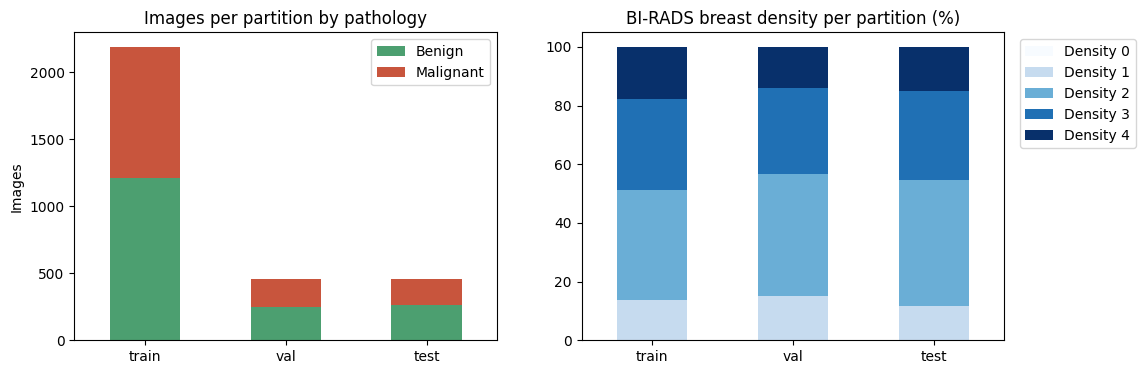

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ct = pd.crosstab(images.split, images.label).reindex(["train", "val", "test"])
ct.columns = ["Benign", "Malignant"]
ct.plot(kind="bar", stacked=True, ax=axes[0], color=["#4C9F70", "#C8553D"], rot=0)
axes[0].set_title("Images per partition by pathology")
axes[0].set_xlabel("")
axes[0].set_ylabel("Images")

dens = pd.crosstab(images.split, images.breast_density, normalize="index").reindex(["train", "val", "test"]) * 100
dens.columns = [f"Density {int(c)}" for c in dens.columns]
dens.plot(kind="bar", stacked=True, ax=axes[1], colormap="Blues", rot=0)
axes[1].set_title("BI-RADS breast density per partition (%)")
axes[1].set_xlabel("")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
savefig(fig, "fig_split_distribution")
plt.show()

## 3. Preprocessing, caching and leakage check

In the draft, every full size JPEG was loaded and put through CLAHE inside `tf.py_function` in every single epoch, straight from the mounted drive. This was really slow, around 1,030 s per epoch at 224 px.

Now each mammogram is processed only once. CLAHE is applied at the original resolution (clip limit 2.0, 8×8 tiles) and then the image is resized with area interpolation. The results are saved as `uint8` arrays. The main experiments use 512 px, because the lesions are very small compared to the whole mammogram and at 224 px a lot of that detail is lost. A 224 px version is still kept to re-run the draft baseline and for the resolution ablation. The ROI masks for the test set are saved too, so they can be used later with Grad-CAM.

In [11]:
S, S_SMALL = CONFIG["img_size"], CONFIG["small_size"]
BUILD_TIMES_PATH = CACHE / "build_times.json"
BUILD_TIMES = json.loads(BUILD_TIMES_PATH.read_text()) if BUILD_TIMES_PATH.exists() else {}


def preprocess_mammogram(path, size):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise IOError(f"Could not read {path}")
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)


def load_union_mask(paths, size):
    mask = np.zeros((size, size), bool)
    for p in paths:
        m = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue
        m = cv2.resize((m > 127).astype(np.float32), (size, size), interpolation=cv2.INTER_AREA)
        mask |= m > 0.05
    return mask


def parallel_map(fn, items, workers=16):
    with ThreadPoolExecutor(max_workers=workers) as ex:
        return list(ex.map(fn, items))


def cached(name, ids, build_fn):
    arr_path, ids_path = CACHE / f"{name}.npy", CACHE / f"{name}_ids.json"
    ids = list(ids)
    if arr_path.exists() and ids_path.exists() and json.loads(ids_path.read_text()) == ids:
        print(f"Loaded cached {name} (built once in {BUILD_TIMES.get(name, float('nan')):.0f}s)")
        return np.load(arr_path)
    t0 = time.time()
    arr = build_fn()
    np.save(arr_path, arr)
    ids_path.write_text(json.dumps(ids))
    BUILD_TIMES[name] = time.time() - t0
    BUILD_TIMES_PATH.write_text(json.dumps(BUILD_TIMES, indent=2))
    print(f"Built {name} {arr.shape} in {BUILD_TIMES[name]:.0f}s")
    return arr


X_full = cached(f"images_{S}", images.image_id,
                lambda: np.stack(parallel_map(lambda p: preprocess_mammogram(p, S), images.full_path)))
X_small = cached(f"images_{S_SMALL}", images.image_id,
                 lambda: np.stack([cv2.resize(x, (S_SMALL, S_SMALL), interpolation=cv2.INTER_AREA) for x in X_full]))

IDX = {s: np.flatnonzero(images.split.values == s) for s in ["train", "val", "test"]}
y_all = images.label.values.astype(np.float32)
test_info = images.iloc[IDX["test"]].reset_index(drop=True)
val_info = images.iloc[IDX["val"]].reset_index(drop=True)
y_test, y_val = test_info.label.values, val_info.label.values

M_test = cached(f"masks_test_{S}_v2", test_info.image_id,
                lambda: np.stack(parallel_map(lambda ps: load_union_mask(ps, S), test_info.mask_paths)))
print("Test images with a non-empty ROI mask:", int(M_test.reshape(len(M_test), -1).any(1).sum()), "/", len(M_test))


def get_split(size, split):
    X = X_full if size == S else X_small
    return X[IDX[split]], y_all[IDX[split]]

Loaded cached images_512 (built once in 574s)
Loaded cached images_224 (built once in 4s)
Loaded cached masks_test_512_v2 (built once in 41s)
Test images with a non-empty ROI mask: 458 / 458


In [12]:
# Check that duplicate views from the same patient do not cross splits
thumbs = np.stack([cv2.resize(x, (64, 64), interpolation=cv2.INTER_AREA) for x in X_full]).astype(np.float32)
dup_pairs = []
for _, grp in images.groupby(["patient_id", "laterality", "view"]):
    idx = grp.index.to_numpy()
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            if np.abs(thumbs[idx[i]] - thumbs[idx[j]]).mean() < 2.0:
                dup_pairs.append((idx[i], idx[j]))
dup_cross = sum(images.split[i] != images.split[j] for i, j in dup_pairs)

# Compare against a naive random image-level split
tr, tmp = train_test_split(np.arange(len(images)), test_size=0.30, random_state=SEED)
va, te = train_test_split(tmp, test_size=0.50, random_state=SEED)
naive_train_patients = set(images.patient_id.values[tr])
naive_leak = np.isin(images.patient_id.values[te], list(naive_train_patients))
naive_split = pd.Series("train", index=images.index)
naive_split[va], naive_split[te] = "val", "test"
naive_dup_cross = sum(naive_split[i] != naive_split[j] for i, j in dup_pairs)

leakage_audit = pd.DataFrame([
    {"Split strategy": "Patient-level (used)", "Test images sharing a patient with training": 0,
     "Near-duplicate pairs crossing partitions": dup_cross},
    {"Split strategy": "Naive image-level (counterfactual)",
     "Test images sharing a patient with training": f"{naive_leak.sum()} ({100 * naive_leak.mean():.1f}%)",
     "Near-duplicate pairs crossing partitions": naive_dup_cross},
])
print("Near-duplicate image pairs found (same patient/side/view):", len(dup_pairs))
display(leakage_audit)
leakage_audit.to_csv(TABLES / "leakage_audit.csv", index=False)
del thumbs
gc.collect()

Near-duplicate image pairs found (same patient/side/view): 71


,Split strategy,Test images sharing a patient with training,Near-duplicate pairs crossing partitions
0,Patient-level (used),0,0
1,Naive image-level (counterfactual),317 (68.0%),29


65

saved /content/drive/MyDrive/CM3070_project/figures/fig_preprocessing_example.png


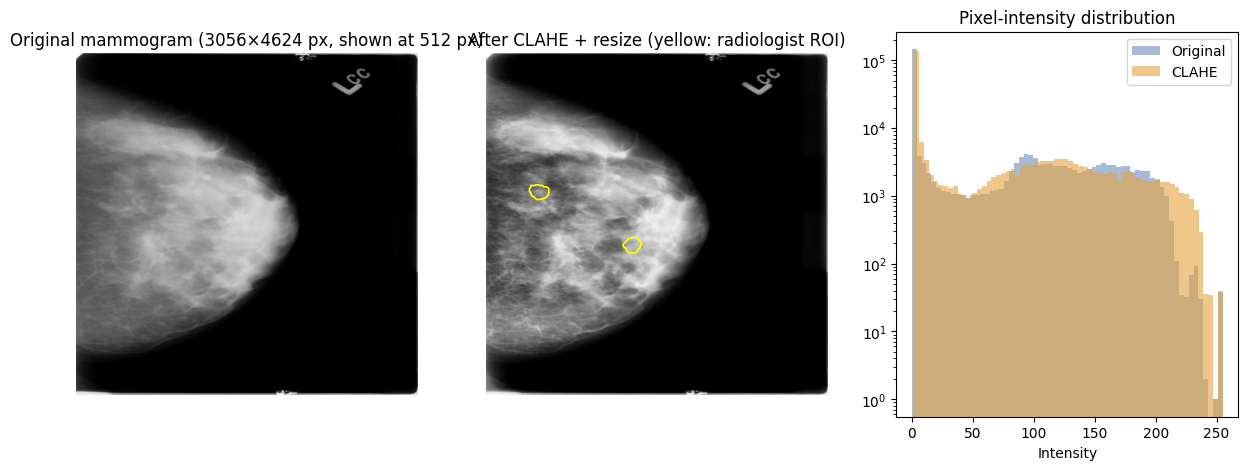

In [13]:
k = int(np.flatnonzero((y_test == 1) & M_test.reshape(len(M_test), -1).any(1))[0])
row = test_info.iloc[k]
raw = cv2.imread(row.full_path, cv2.IMREAD_GRAYSCALE)
raw_small = cv2.resize(raw, (S, S), interpolation=cv2.INTER_AREA)
clahe_small = X_full[IDX["test"][k]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(raw_small, cmap="gray")
axes[0].set_title(f"Original mammogram ({raw.shape[1]}×{raw.shape[0]} px, shown at {S} px)")
axes[1].imshow(clahe_small, cmap="gray")
axes[1].contour(M_test[k], levels=[0.5], colors="yellow", linewidths=1.2)
axes[1].set_title("After CLAHE + resize (yellow: radiologist ROI)")
for ax in axes[:2]:
    ax.axis("off")
axes[2].hist(raw_small.ravel(), bins=64, alpha=0.6, label="Original", color="#6C8EBF")
axes[2].hist(clahe_small.ravel(), bins=64, alpha=0.6, label="CLAHE", color="#E6A23C")
axes[2].set_yscale("log")
axes[2].set_title("Pixel-intensity distribution")
axes[2].set_xlabel("Intensity")
axes[2].legend()
savefig(fig, "fig_preprocessing_example")
plt.show()

## 4. Input pipeline and augmentation

The saved arrays go into a `tf.data` pipeline that shuffles, batches, casts and prefetches. The augmentation only uses changes that could realistically happen when a mammogram is taken: horizontal flips (a flipped left breast looks like a right breast), rotation of around ±11°, ±10% zoom, ±5% shift and a small contrast change. Vertical flips and colour changes are not used. The augmentation is part of the model so it runs on the GPU, and it is only used during training.

saved /content/drive/MyDrive/CM3070_project/figures/fig_augmentation_examples.png


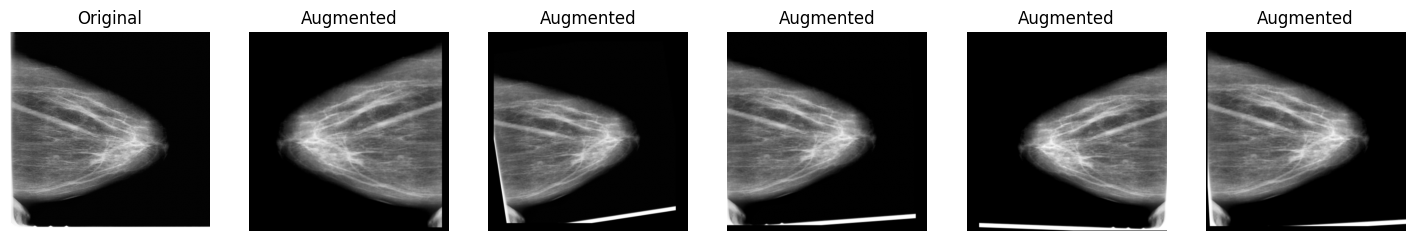

In [14]:
AUTOTUNE = tf.data.AUTOTUNE


def make_ds(X, y, batch_size, shuffle):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size)
    return ds.map(lambda a, b: (tf.cast(a, tf.float32)[..., None], b),
                  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


def build_augment(seed=SEED):
    return keras.Sequential([
        layers.RandomFlip("horizontal", seed=seed),
        layers.RandomRotation(0.03, fill_mode="constant", seed=seed + 1),
        layers.RandomZoom(0.10, fill_mode="constant", seed=seed + 2),
        layers.RandomTranslation(0.05, 0.05, fill_mode="constant", seed=seed + 3),
        layers.RandomContrast(0.15, seed=seed + 4),
    ], name="augment")


aug = build_augment()
sample = tf.cast(X_full[IDX["train"][0]][None, ..., None], tf.float32)
fig, axes = plt.subplots(1, 6, figsize=(18, 3.4))
axes[0].imshow(sample[0, ..., 0], cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
for ax in axes[1:]:
    ax.imshow(tf.cast(aug(sample, training=True), tf.float32)[0, ..., 0], cmap="gray", vmin=0, vmax=255)
    ax.set_title("Augmented")
for ax in axes:
    ax.axis("off")
savefig(fig, "fig_augmentation_examples")
plt.show()

## 5. Models

All the models are built the same way: input, augmentation (optional), prep, backbone, head.

- prep turns the grayscale mammogram into the format the backbone expects, which means copying it into 3 channels and applying that backbone's ImageNet normalisation.
- backbone is either a CNN pre-trained on ImageNet or a custom CNN trained from scratch.
- head is the same classifier as in the draft: global average pooling, batch norm, dropout 0.4, dense 256, dropout 0.3, sigmoid. The logit before the sigmoid is also kept because Grad-CAM needs it.

Transfer learning is done in two phases. First the backbone is frozen and only the head is trained (lr 1e-3). Then the last block of the backbone is unfrozen (`conv5` for DenseNet121) and trained with lr 3e-5. The BatchNorm layers stay frozen in inference mode, because with small batches they would mess up the ImageNet statistics. Both phases use early stopping on validation AUC and keep the best weights.

Most of the models use focal loss (Lin et al., 2017): $FL(p_t) = -\alpha_t (1-p_t)^{\gamma}\log(p_t)$ with $\gamma = 2$, which gives less weight to the easy examples. $\alpha$ is set to the fraction of benign images in the training set (about 0.55), so mistakes on malignant cases count a bit more.

In [15]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
BACKBONES = {
    "densenet121": dict(fn=keras.applications.DenseNet121, unfreeze=("conv5",)),
    "efficientnetb0": dict(fn=keras.applications.EfficientNetB0, unfreeze=("block6", "block7", "top")),
    "resnet50v2": dict(fn=keras.applications.ResNet50V2, unfreeze=("conv5", "post")),
}


def build_prep(arch, size):
    inp = keras.Input((size, size, 1))
    if arch == "custom":
        return keras.Model(inp, layers.Rescaling(1 / 255)(inp), name="prep")
    x = layers.Concatenate()([inp, inp, inp])
    if arch == "densenet121":
        x = layers.Rescaling(1 / 255)(x)
        x = layers.Normalization(mean=IMAGENET_MEAN, variance=[s ** 2 for s in IMAGENET_STD])(x)
    elif arch == "resnet50v2":
        x = layers.Rescaling(1 / 127.5, offset=-1)(x)
    return keras.Model(inp, x, name="prep")


def build_custom_backbone(size):
    inp = keras.Input((size, size, 1))
    x = layers.Conv2D(32, 5, strides=2, padding="same", use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    for filters in (32, 64, 128, 256):
        for _ in range(2):
            x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
            x = layers.BatchNormalization()(x)
            x = layers.ReLU()(x)
        x = layers.MaxPooling2D()(x)
    return keras.Model(inp, x, name="backbone")


def build_backbone(arch, size, pretrained=True):
    if arch == "custom":
        return build_custom_backbone(size)
    weights = CONFIG["imagenet_weights"] if pretrained else None
    if arch == "densenet121" or not weights:
        return BACKBONES[arch]["fn"](include_top=False, weights=weights, input_shape=(size, size, 3), name="backbone")
    # EfficientNet/ResNet use the name to build the weights download URL, so load with the default name and copy the weights
    base = BACKBONES[arch]["fn"](include_top=False, weights=weights, input_shape=(size, size, 3))
    backbone = BACKBONES[arch]["fn"](include_top=False, weights=None, input_shape=(size, size, 3), name="backbone")
    backbone.set_weights(base.get_weights())
    del base
    return backbone


def build_head(feat_shape):
    return keras.Sequential([
        keras.Input(feat_shape),
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, dtype="float32", name="logit"),
        layers.Activation("sigmoid", dtype="float32", name="prob"),
    ], name="head")


def build_model(exp, name, pretrained=True):
    size, arch = exp["size"], exp["arch"]
    inp = keras.Input((size, size, 1), name="mammogram")
    x = build_augment()(inp) if exp["augment"] else inp
    x = build_prep(arch, size)(x)
    backbone = build_backbone(arch, size, pretrained)
    feats = backbone(x) if arch == "custom" else backbone(x, training=False)
    out = build_head(tuple(backbone.output.shape[1:]))(feats)
    return keras.Model(inp, out, name=name)


def set_trainable(model, arch, mode):
    backbone = model.get_layer("backbone")
    backbone.trainable = mode in ("all", "top")
    if mode == "top":
        prefixes = BACKBONES[arch]["unfreeze"]
        for layer in backbone.layers:
            layer.trainable = layer.name.startswith(prefixes) and not isinstance(layer, layers.BatchNormalization)


def count_params(weights):
    return int(sum(np.prod(w.shape) for w in weights))

In [16]:
FOCAL_ALPHA = 1 - float(y_all[IDX["train"]].mean())
print(f"Focal-loss alpha (share of benign training images): {FOCAL_ALPHA:.3f}")


def make_loss(kind):
    if kind == "focal":
        return keras.losses.BinaryFocalCrossentropy(apply_class_balancing=True, alpha=FOCAL_ALPHA, gamma=2.0)
    return keras.losses.BinaryCrossentropy()


def compile_model(model, lr, loss):
    model.compile(optimizer=keras.optimizers.Adam(lr), loss=loss, jit_compile=False,
                  metrics=[keras.metrics.AUC(name="auc"), keras.metrics.Recall(name="recall"),
                           keras.metrics.Precision(name="precision"), keras.metrics.BinaryAccuracy(name="accuracy")])


size_rows = []
for arch in ([] if (TABLES / "model_sizes.csv").exists() else ["custom", "densenet121", "efficientnetb0", "resnet50v2"]):
    keras.backend.clear_session()
    probe = build_model(dict(arch=arch, size=S, augment=False), f"probe_{arch}")
    row = {"Backbone": arch, "Total parameters": probe.count_params(),
           "Feature map at %d px" % S: "×".join(str(d) for d in probe.get_layer("backbone").output.shape[1:])}
    if arch == "custom":
        set_trainable(probe, arch, "all")
        row["Trainable (head phase)"] = "-"
        row["Trainable (fine-tune / full)"] = count_params(probe.trainable_weights)
    else:
        set_trainable(probe, arch, "none")
        row["Trainable (head phase)"] = count_params(probe.trainable_weights)
        set_trainable(probe, arch, "top")
        row["Trainable (fine-tune / full)"] = count_params(probe.trainable_weights)
    size_rows.append(row)
    del probe
if size_rows:
    pd.DataFrame(size_rows).to_csv(TABLES / "model_sizes.csv", index=False)
model_sizes = pd.read_csv(TABLES / "model_sizes.csv")
display(model_sizes)

Focal-loss alpha (share of benign training images): 0.554


,Backbone,Total parameters,Feature map at 512 px,Trainable (head phase),Trainable (fine-tune / full)
0,custom,1251489,16×16×256,-,1248993
1,densenet121,7304257,16×16×1024,264705,2394625
2,efficientnetb0,4382884,16×16×1280,330753,3460637
3,resnet50v2,24097793,16×16×2048,528897,15479297


## 6. Experiments

| ID | Backbone | Input | Loss | Augment | Why | Training time |
|---|---|---|---|---|---|---|
| B0 | DenseNet121 (frozen, 5 epochs) | 224 | BCE | – | Draft baseline, same settings as the draft but on the new pipeline | 2 min |
| M1 | Custom CNN (from scratch) | 512 | Focal | ✓ | To see if ImageNet pre-training helps at all | 17 min |
| M2 | DenseNet121 fine-tuned | 512 | BCE | ✓ | To see the effect of fine-tuning | 32 min |
| M3 | DenseNet121 fine-tuned | 512 | Focal | ✓ | Proposed model | 33 min |
| A1 | DenseNet121 fine-tuned | 512 | Focal | – | Ablation: no augmentation | 22 min |
| A2 | DenseNet121 fine-tuned | 224 | Focal | ✓ | Ablation: lower resolution | 5 min |
| A3 | EfficientNetB0 fine-tuned | 512 | Focal | ✓ | Different backbone | 19 min |
| A4 | ResNet50V2 fine-tuned | 512 | Focal | ✓ | Different backbone | 24 min |

The training times are from the full training run (see the training efficiency table in section 7). The draft feedback asked for B0, M1, M2 and M3 as the main ones. To run only some of them, set `CONFIG["run_experiments"]`, for example `["B0_densenet_frozen_bce_224", "M3_densenet_ft_focal_512"]`.

In [17]:
def transfer_phases(head_epochs=8, ft_epochs=25):
    return [dict(name="head", trainable="none", lr=1e-3, epochs=head_epochs, patience=3),
            dict(name="finetune", trainable="top", lr=3e-5, epochs=ft_epochs, patience=6)]


EXPERIMENTS = {
    "B0_densenet_frozen_bce_224": dict(
        arch="densenet121", size=S_SMALL, loss="bce", augment=False, batch_size=32, select_best=False,
        phases=[dict(name="head", trainable="none", lr=1e-4, epochs=5, patience=None)],
        role="Draft baseline re-run (identical configuration)"),
    "M1_custom_cnn_focal_512": dict(
        arch="custom", size=S, loss="focal", augment=True,
        phases=[dict(name="full", trainable="all", lr=1e-3, epochs=40, patience=8)],
        role="Custom CNN trained from scratch"),
    "M2_densenet_ft_bce_512": dict(
        arch="densenet121", size=S, loss="bce", augment=True, phases=transfer_phases(),
        role="Fine-tuned DenseNet121, binary cross-entropy"),
    "M3_densenet_ft_focal_512": dict(
        arch="densenet121", size=S, loss="focal", augment=True, phases=transfer_phases(),
        role="Proposed: fine-tuned DenseNet121, focal loss"),
    "A1_densenet_ft_focal_noaug_512": dict(
        arch="densenet121", size=S, loss="focal", augment=False, phases=transfer_phases(),
        role="Ablation: no augmentation"),
    "A2_densenet_ft_focal_224": dict(
        arch="densenet121", size=S_SMALL, loss="focal", augment=True, phases=transfer_phases(),
        role="Ablation: 224 px input"),
    "A3_efficientnetb0_ft_focal_512": dict(
        arch="efficientnetb0", size=S, loss="focal", augment=True, phases=transfer_phases(),
        role="Alternative backbone: EfficientNetB0"),
    "A4_resnet50v2_ft_focal_512": dict(
        arch="resnet50v2", size=S, loss="focal", augment=True, phases=transfer_phases(),
        role="Alternative backbone: ResNet50V2"),
}
PROPOSED = "M3_densenet_ft_focal_512"
for exp in EXPERIMENTS.values():
    exp.setdefault("batch_size", CONFIG["batch_size"])
    exp.setdefault("select_best", True)

exp_table = pd.DataFrame([{"ID": n, "Backbone": e["arch"], "Input": e["size"], "Loss": e["loss"],
                           "Augment": e["augment"], "Batch": e["batch_size"],
                           "Phases": " --> ".join(f"{p['name']} (lr {p['lr']:g}, ≤{p['epochs']} ep)" for p in e["phases"]),
                           "Role": e["role"]} for n, e in EXPERIMENTS.items()])
exp_table.to_csv(TABLES / "experiments.csv", index=False)
display(exp_table)

,ID,Backbone,Input,Loss,Augment,Batch,Phases,Role
0,B0_densenet_frozen_bce_224,densenet121,224,bce,False,32,"head (lr 0.0001, ≤5 ep)",Draft baseline re-run (identical configuration)
1,M1_custom_cnn_focal_512,custom,512,focal,True,16,"full (lr 0.001, ≤40 ep)",Custom CNN trained from scratch
2,M2_densenet_ft_bce_512,densenet121,512,bce,True,16,"head (lr 0.001, ≤8 ep) --> finetune (lr 3e-05,...","Fine-tuned DenseNet121, binary cross-entropy"
3,M3_densenet_ft_focal_512,densenet121,512,focal,True,16,"head (lr 0.001, ≤8 ep) --> finetune (lr 3e-05,...","Proposed: fine-tuned DenseNet121, focal loss"
4,A1_densenet_ft_focal_noaug_512,densenet121,512,focal,False,16,"head (lr 0.001, ≤8 ep) --> finetune (lr 3e-05,...",Ablation: no augmentation
5,A2_densenet_ft_focal_224,densenet121,224,focal,True,16,"head (lr 0.001, ≤8 ep) --> finetune (lr 3e-05,...",Ablation: 224 px input
6,A3_efficientnetb0_ft_focal_512,efficientnetb0,512,focal,True,16,"head (lr 0.001, ≤8 ep) --> finetune (lr 3e-05,...",Alternative backbone: EfficientNetB0
7,A4_resnet50v2_ft_focal_512,resnet50v2,512,focal,True,16,"head (lr 0.001, ≤8 ep) --> finetune (lr 3e-05,...",Alternative backbone: ResNet50V2


In [18]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self._start)


def cap_epochs(n):
    return min(n, CONFIG["max_epochs"]) if CONFIG["max_epochs"] else n


def predict_probs(model, X, batch_size=32):
    ds = make_ds(X, np.zeros(len(X), np.float32), batch_size, shuffle=False)
    return model.predict(ds, verbose=0).ravel().astype(float)


def run_experiment(name, exp):
    weights_path, preds_path = MODELS / f"{name}.weights.h5", PREDS / f"{name}.csv"
    meta_path = LOGS / f"{name}_meta.json"
    if weights_path.exists() and preds_path.exists() and meta_path.exists():
        print(f"[skip] {name} already trained")
        return
    print(f"\n=== {name}: {exp['role']} ===")
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)
    X_tr, y_tr = get_split(exp["size"], "train")
    X_va, y_va = get_split(exp["size"], "val")
    train_ds = make_ds(X_tr, y_tr, exp["batch_size"], shuffle=True)
    val_ds = make_ds(X_va, y_va, exp["batch_size"], shuffle=False)

    model = build_model(exp, name)
    loss = make_loss(exp["loss"])
    best_ckpt = MODELS / f"{name}.best.weights.h5"
    history, best_auc, start = [], -np.inf, time.time()
    for phase in exp["phases"]:
        set_trainable(model, exp["arch"], phase["trainable"])
        compile_model(model, phase["lr"], loss)
        timer = EpochTimer()
        callbacks = [timer, keras.callbacks.TerminateOnNaN()]
        if exp["select_best"]:
            callbacks.append(keras.callbacks.ModelCheckpoint(
                best_ckpt, monitor="val_auc", mode="max", save_best_only=True, save_weights_only=True,
                initial_value_threshold=best_auc if np.isfinite(best_auc) else None))
        if phase["patience"]:
            callbacks += [
                keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=phase["patience"]),
                keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5,
                                                  patience=max(2, phase["patience"] // 2), min_lr=1e-6)]
        trainable = count_params(model.trainable_weights)
        hist = model.fit(train_ds, validation_data=val_ds, epochs=cap_epochs(phase["epochs"]),
                         callbacks=callbacks, verbose=2)
        for i, seconds in enumerate(timer.times):
            history.append({"phase": phase["name"], "epoch": len(history) + 1, "epoch_time_s": seconds,
                            "trainable_params": trainable,
                            **{k: float(v[i]) if i < len(v) else np.nan for k, v in hist.history.items()}})
        best_auc = max(best_auc, max(hist.history["val_auc"]))
        if exp["select_best"] and best_ckpt.exists():
            model.load_weights(best_ckpt)

    train_seconds = time.time() - start
    model.save_weights(weights_path)
    frames = []
    for split in ["val", "test"]:
        X, y = get_split(exp["size"], split)
        frames.append(pd.DataFrame({"image_id": images.image_id.values[IDX[split]], "split": split,
                                    "label": y.astype(int), "prob": predict_probs(model, X, exp["batch_size"])}))
    preds_df = pd.concat(frames)
    preds_df.to_csv(preds_path, index=False)
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(LOGS / f"{name}_history.csv", index=False)
    meta_path.write_text(json.dumps({
        "name": name, "role": exp["role"], "arch": exp["arch"], "size": exp["size"], "loss": exp["loss"],
        "augment": exp["augment"], "batch_size": exp["batch_size"], "phases": exp["phases"],
        "total_params": model.count_params(), "train_seconds": train_seconds, "epochs_run": len(history),
        "best_val_auc": best_auc,
        "mean_epoch_seconds": hist_df.groupby("phase", sort=False)["epoch_time_s"].mean().to_dict(),
    }, indent=2, default=str))
    v, t = (preds_df[preds_df.split == s] for s in ["val", "test"])
    print(f"{name}: val AUC {roc_auc_score(v.label, v.prob):.3f} | test AUC {roc_auc_score(t.label, t.prob):.3f} "
          f"| {len(history)} epochs in {train_seconds / 60:.1f} min")
    del model
    gc.collect()

In [19]:
for name in CONFIG["run_experiments"] or list(EXPERIMENTS):
    run_experiment(name, EXPERIMENTS[name])

[skip] B0_densenet_frozen_bce_224 already trained
[skip] M1_custom_cnn_focal_512 already trained
[skip] M2_densenet_ft_bce_512 already trained
[skip] M3_densenet_ft_focal_512 already trained
[skip] A1_densenet_ft_focal_noaug_512 already trained
[skip] A2_densenet_ft_focal_224 already trained
[skip] A3_efficientnetb0_ft_focal_512 already trained
[skip] A4_resnet50v2_ft_focal_512 already trained


## 7. Evaluation on the test set

Every model is evaluated in the same way:

- ROC-AUC and PR-AUC (average precision), which don't depend on a threshold.
- The thresholds are picked on the validation set only and then applied once to the test set. There are three: the default 0.5, Youden's J (balances sensitivity and specificity), and the highest threshold that still gets at least 90% sensitivity on validation (closer to what screening would need).
- 95% confidence intervals from a bootstrap at the patient level. Patients are resampled instead of images because images from the same patient are not independent. All the models use the same resamples, so the differences between models are paired.
- Confusion matrices, precision (PPV), specificity, NPV and F1 at each threshold.

In [20]:
available = [n for n in EXPERIMENTS if (PREDS / f"{n}.csv").exists()]
assert PROPOSED in available, f"Train {PROPOSED} before running the evaluation"
preds = {n: pd.read_csv(PREDS / f"{n}.csv") for n in available}
meta = {n: json.loads((LOGS / f"{n}_meta.json").read_text()) for n in available}


def split_probs(name, split):
    df = preds[name][preds[name].split == split]
    ref = test_info if split == "test" else val_info
    assert (df.image_id.values == ref.image_id.values).all()
    return df.prob.values


print("Models with predictions:", available)

Models with predictions: ['B0_densenet_frozen_bce_224', 'M1_custom_cnn_focal_512', 'M2_densenet_ft_bce_512', 'M3_densenet_ft_focal_512', 'A1_densenet_ft_focal_noaug_512', 'A2_densenet_ft_focal_224', 'A3_efficientnetb0_ft_focal_512', 'A4_resnet50v2_ft_focal_512']


In [21]:
METRICS = ["sensitivity", "specificity", "ppv", "npv", "f1", "accuracy", "balanced_accuracy"]


def fast_metrics(y, p, t):
    pred = p >= t
    tp, fp = int(np.sum(pred & (y == 1))), int(np.sum(pred & (y == 0)))
    fn, tn = int(np.sum(~pred & (y == 1))), int(np.sum(~pred & (y == 0)))
    div = lambda a, b: a / b if b else np.nan
    sens, spec = div(tp, tp + fn), div(tn, tn + fp)
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn, "sensitivity": sens, "specificity": spec,
            "ppv": div(tp, tp + fp), "npv": div(tn, tn + fn), "f1": div(2 * tp, 2 * tp + fp + fn),
            "accuracy": div(tp + tn, len(y)), "balanced_accuracy": (sens + spec) / 2}


class PatientBootstrap:
    # Resample patients with replacement, all images of a picked patient come with them
    def __init__(self, patient_ids, n_boot, seed=SEED):
        codes, uniques = pd.factorize(pd.Series(patient_ids))
        members = [np.flatnonzero(codes == c) for c in range(len(uniques))]
        rng = np.random.default_rng(seed)
        self.samples = [np.concatenate([members[g] for g in rng.integers(0, len(members), len(members))])
                        for _ in range(n_boot)]

    def ci(self, fn, *arrays):
        point = fn(*arrays)
        stats = []
        for idx in self.samples:
            try:
                v = fn(*(a[idx] for a in arrays))
            except ValueError:
                continue
            if np.isfinite(v):
                stats.append(v)
        if not stats:
            return point, np.nan, np.nan
        lo, hi = np.percentile(stats, [2.5, 97.5])
        return point, lo, hi


def ci_metrics(boot, y, p, t):
    point = fast_metrics(y, p, t)
    samples = [fast_metrics(y[idx], p[idx], t) for idx in boot.samples]
    out = {}
    for m in METRICS:
        vals = np.array([s[m] for s in samples], float)
        vals = vals[np.isfinite(vals)]
        lo, hi = np.percentile(vals, [2.5, 97.5]) if len(vals) else (np.nan, np.nan)
        out[m] = (point[m], lo, hi)
    return point, out


def paired_auc_diff(boot, y, p_a, p_b):
    diffs = []
    for idx in boot.samples:
        yy = y[idx]
        if yy.min() != yy.max():
            diffs.append(roc_auc_score(yy, p_a[idx]) - roc_auc_score(yy, p_b[idx]))
    diffs = np.array(diffs)
    p_value = min(1.0, 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return roc_auc_score(y, p_a) - roc_auc_score(y, p_b), lo, hi, p_value


def select_thresholds(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    thr = np.clip(thr, 0, 1)
    return {"0.50": 0.5, "youden": float(thr[np.argmax(tpr - fpr)]), "sens90": float(thr[np.argmax(tpr >= 0.90)])}


def fmt(ci, pct=False):
    pt, lo, hi = ci[:3]
    if not np.isfinite(pt):
        return "n/a"
    if pct:
        return f"{100 * pt:.1f} ({100 * lo:.1f}–{100 * hi:.1f})"
    return f"{pt:.3f} ({lo:.3f}–{hi:.3f})"

In [22]:
boot_test = PatientBootstrap(test_info.patient_id.values, CONFIG["n_bootstrap"])
THRESHOLDS, AUC_CI, long_rows, wide_rows = {}, {}, [], []
for name in available:
    p_val, p_test = split_probs(name, "val"), split_probs(name, "test")
    THRESHOLDS[name] = select_thresholds(y_val, p_val)
    AUC_CI[name] = boot_test.ci(roc_auc_score, y_test, p_test)
    ap = boot_test.ci(average_precision_score, y_test, p_test)
    long_rows += [{"model": name, "threshold": "-", "metric": "roc_auc", "value": AUC_CI[name][0],
                   "lo": AUC_CI[name][1], "hi": AUC_CI[name][2]},
                  {"model": name, "threshold": "-", "metric": "pr_auc", "value": ap[0], "lo": ap[1], "hi": ap[2]}]
    wide = {"Model": name, "Val AUC": round(roc_auc_score(y_val, p_val), 3),
            "Test AUC (95% CI)": fmt(AUC_CI[name]), "Test PR-AUC (95% CI)": fmt(ap)}
    for tname, t in THRESHOLDS[name].items():
        point, cis = ci_metrics(boot_test, y_test, p_test, t)
        for m, (v, lo, hi) in cis.items():
            long_rows.append({"model": name, "threshold": tname, "threshold_value": t, "metric": m,
                              "value": v, "lo": lo, "hi": hi})
        for m in ["tp", "fp", "fn", "tn"]:
            long_rows.append({"model": name, "threshold": tname, "threshold_value": t, "metric": m, "value": point[m]})
        if tname != "0.50":
            tag = "Youden" if tname == "youden" else "Sens≥90%"
            for m, label in [("sensitivity", "Sens"), ("specificity", "Spec"), ("ppv", "PPV")]:
                wide[f"{label} % @ {tag}"] = fmt(cis[m], pct=True)
    wide_rows.append(wide)

metrics_long = pd.DataFrame(long_rows)
metrics_long.to_csv(TABLES / "test_metrics_long.csv", index=False)
results_table = pd.DataFrame(wide_rows)
results_table.to_csv(TABLES / "test_metrics.csv", index=False)
(TABLES / "thresholds.json").write_text(json.dumps(THRESHOLDS, indent=2))
display(results_table)

,Model,Val AUC,Test AUC (95% CI),Test PR-AUC (95% CI),Sens % @ Youden,Spec % @ Youden,PPV % @ Youden,Sens % @ Sens≥90%,Spec % @ Sens≥90%,PPV % @ Sens≥90%
0,B0_densenet_frozen_bce_224,0.680,0.679 (0.620–0.733),0.571 (0.477–0.663),47.2 (39.6–54.9),76.2 (69.9–81.8),59.1 (49.0–68.2),87.6 (81.6–92.7),33.6 (27.2–39.8),49.0 (41.9–55.9)
1,M1_custom_cnn_focal_512,0.719,0.653 (0.590–0.711),0.568 (0.485–0.659),64.8 (55.8–73.1),54.7 (46.5–62.6),51.0 (43.0–59.2),84.5 (77.7–90.6),34.0 (26.4–41.9),48.2 (40.8–55.5)
2,M2_densenet_ft_bce_512,0.752,0.748 (0.690–0.805),0.674 (0.589–0.760),74.1 (66.7–81.7),64.9 (58.0–71.6),60.6 (52.6–68.5),90.2 (84.7–94.9),38.9 (31.1–46.7),51.8 (44.9–59.1)
3,M3_densenet_ft_focal_512,0.752,0.730 (0.670–0.789),0.658 (0.570–0.746),68.4 (60.8–76.4),67.2 (60.6–73.6),60.3 (52.2–68.4),89.1 (83.7–94.0),35.1 (27.0–43.3),50.0 (43.3–57.1)
4,A1_densenet_ft_focal_noaug_512,0.785,0.769 (0.714–0.821),0.701 (0.621–0.778),72.0 (64.1–79.5),64.9 (57.1–72.2),59.9 (51.6–68.0),86.0 (79.7–91.9),51.3 (42.9–59.5),56.3 (48.8–64.0)
5,A2_densenet_ft_focal_224,0.676,0.640 (0.582–0.699),0.546 (0.457–0.634),57.5 (49.5–65.3),61.5 (54.9–68.0),52.1 (43.9–60.2),83.9 (78.0–89.4),30.2 (23.0–37.6),46.7 (39.9–53.5)
6,A3_efficientnetb0_ft_focal_512,0.780,0.711 (0.654–0.768),0.640 (0.548–0.735),69.9 (62.4–77.3),54.3 (46.6–62.0),52.7 (44.6–60.9),89.1 (83.9–93.8),39.2 (31.2–47.4),51.7 (44.4–59.0)
7,A4_resnet50v2_ft_focal_512,0.739,0.751 (0.694–0.806),0.706 (0.619–0.788),68.9 (60.7–76.9),65.3 (58.5–71.9),59.1 (50.5–67.4),88.6 (83.4–93.5),38.9 (31.5–46.1),51.4 (44.2–58.3)


In [23]:
p_prop_test = split_probs(PROPOSED, "test")
cmp_rows = []
for name in available:
    if name == PROPOSED:
        continue
    d, lo, hi, pv = paired_auc_diff(boot_test, y_test, p_prop_test, split_probs(name, "test"))
    cmp_rows.append({"Proposed vs": name, "ΔAUC": f"{d:+.3f}", "95% CI": f"{lo:+.3f} to {hi:+.3f}",
                     "p (paired bootstrap)": f"{pv:.3f}"})
auc_comparison = pd.DataFrame(cmp_rows)
auc_comparison.to_csv(TABLES / "auc_comparison.csv", index=False)
display(auc_comparison)

,Proposed vs,ΔAUC,95% CI,p (paired bootstrap)
0,B0_densenet_frozen_bce_224,+0.051,-0.006 to +0.108,0.074
1,M1_custom_cnn_focal_512,+0.077,+0.002 to +0.152,0.046
2,M2_densenet_ft_bce_512,-0.018,-0.036 to +0.000,0.053
3,A1_densenet_ft_focal_noaug_512,-0.039,-0.077 to -0.000,0.048
4,A2_densenet_ft_focal_224,+0.089,+0.036 to +0.142,0.000
5,A3_efficientnetb0_ft_focal_512,+0.019,-0.027 to +0.068,0.459
6,A4_resnet50v2_ft_focal_512,-0.022,-0.061 to +0.022,0.303


saved /content/drive/MyDrive/CM3070_project/figures/fig_roc_pr_all_models.png


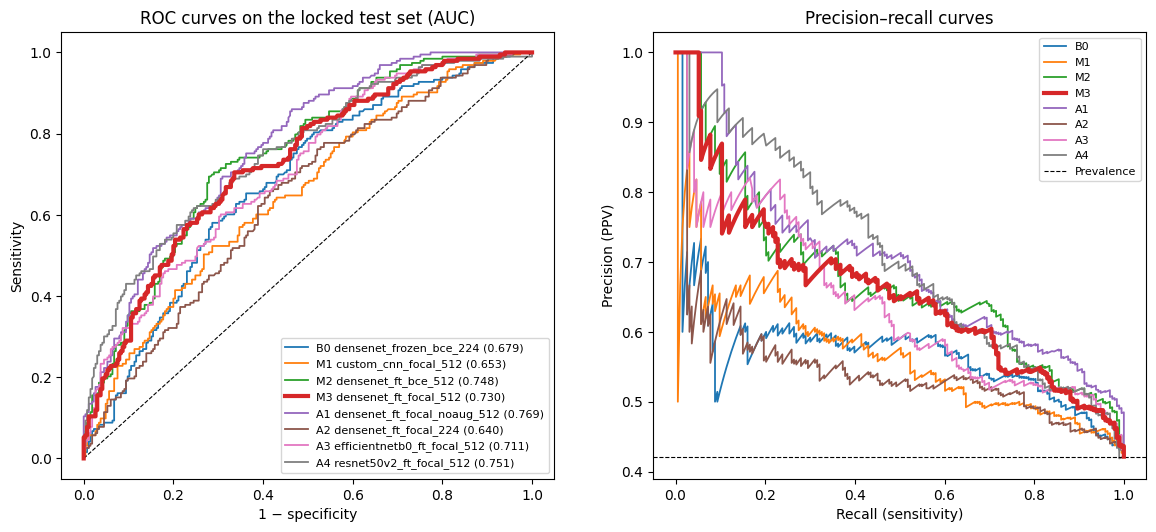

saved /content/drive/MyDrive/CM3070_project/figures/fig_confusion_matrices.png


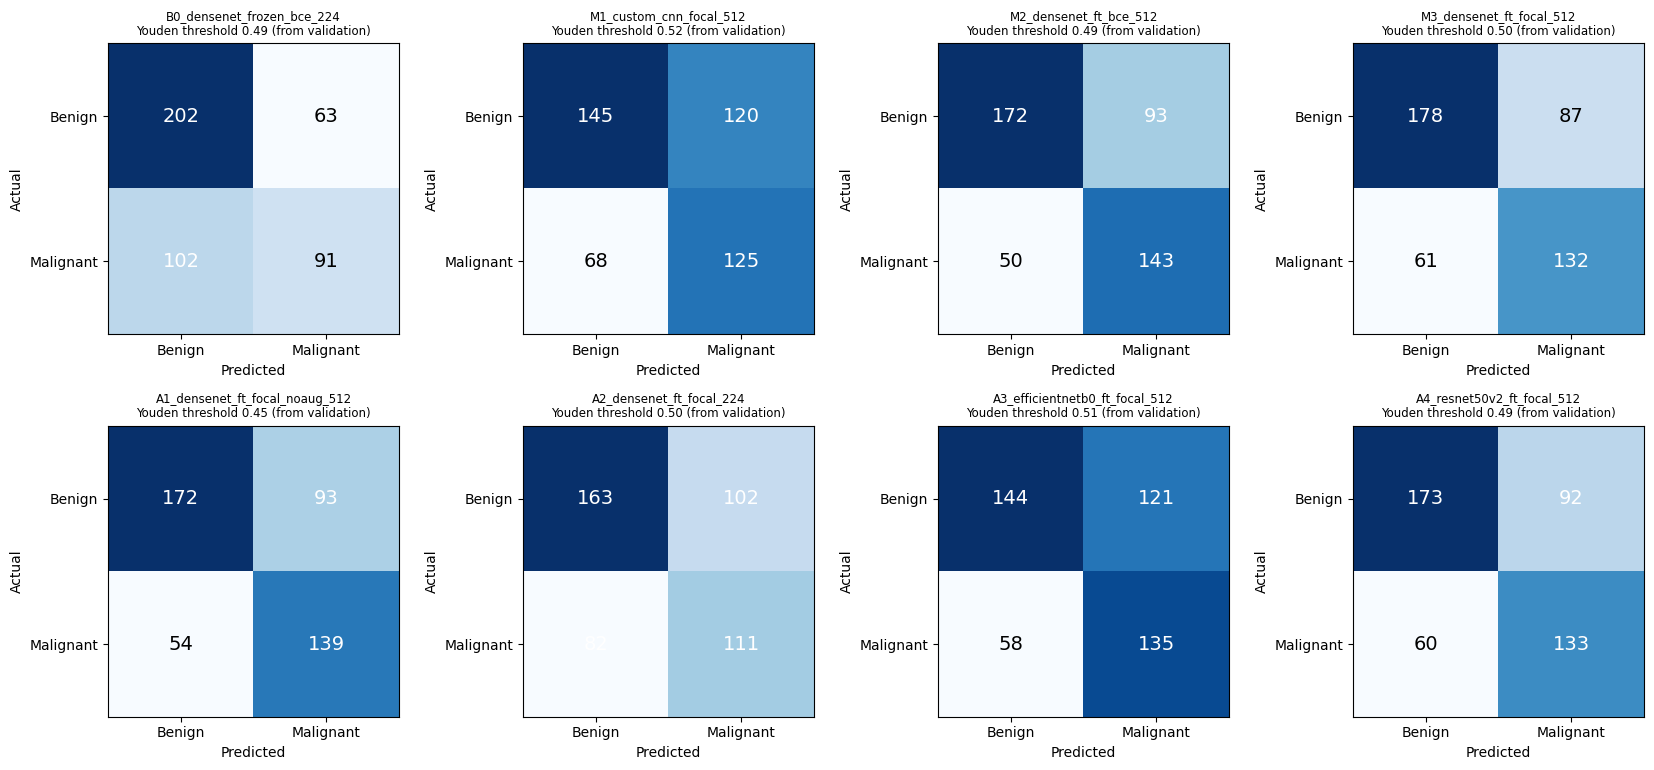

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
for name in available:
    p = split_probs(name, "test")
    fpr, tpr, _ = roc_curve(y_test, p)
    prec, rec, _ = precision_recall_curve(y_test, p)
    lw, z = (3, 3) if name == PROPOSED else (1.3, 2)
    axes[0].plot(fpr, tpr, lw=lw, zorder=z, label=f"{name.split('_')[0]} {name.split('_', 1)[1]} ({AUC_CI[name][0]:.3f})")
    axes[1].plot(rec, prec, lw=lw, zorder=z, label=name.split("_")[0])
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set(xlabel="1 − specificity", ylabel="Sensitivity", title="ROC curves on the locked test set (AUC)")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=0.8, label="Prevalence")
axes[1].set(xlabel="Recall (sensitivity)", ylabel="Precision (PPV)", title="Precision–recall curves")
axes[1].legend(fontsize=8)
savefig(fig, "fig_roc_pr_all_models")
plt.show()

cols = 4
rows_ = math.ceil(len(available) / cols)
fig, axes = plt.subplots(rows_, cols, figsize=(4.2 * cols, 3.9 * rows_))
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, available):
    t = THRESHOLDS[name]["youden"]
    m = fast_metrics(y_test, split_probs(name, "test"), t)
    cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, v, ha="center", va="center", fontsize=14, color="white" if v > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], ["Benign", "Malignant"])
    ax.set_yticks([0, 1], ["Benign", "Malignant"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name}\nYouden threshold {t:.2f} (from validation)", fontsize=8.5)
for ax in axes[len(available):]:
    ax.axis("off")
fig.tight_layout()
savefig(fig, "fig_confusion_matrices")
plt.show()

saved /content/drive/MyDrive/CM3070_project/figures/fig_training_curves.png


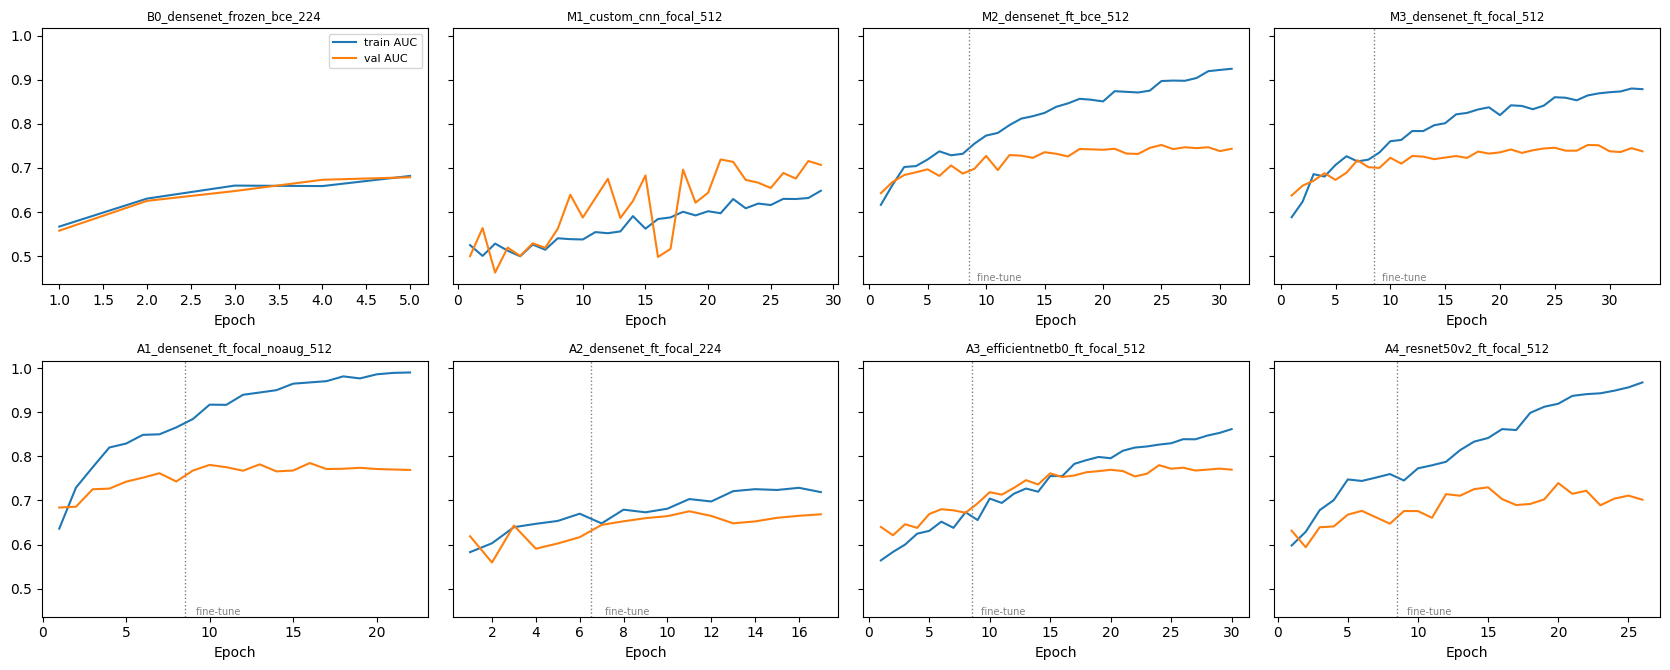

Same configuration, new pipeline: 51× faster per epoch
One-off preprocessing cost (s): {'images_512': 574, 'images_224': 4, 'masks_test_512': 1, 'masks_test_512_v2': 41}


,Run,Input,Epochs,Mean epoch (s),Total (min)
0,Draft pipeline (per-epoch JPEG decode + CLAHE),224,5,1032.8,86.1
1,B0_densenet_frozen_bce_224,224,5,20.1,1.7
2,M1_custom_cnn_focal_512,512,29,35.3,17.3
3,M2_densenet_ft_bce_512,512,31,59.4,31.7
4,M3_densenet_ft_focal_512,512,33,58.3,33.1
5,A1_densenet_ft_focal_noaug_512,512,22,58.0,22.2
6,A2_densenet_ft_focal_224,224,17,16.5,5.3
7,A3_efficientnetb0_ft_focal_512,512,30,37.0,19.4
8,A4_resnet50v2_ft_focal_512,512,26,53.2,23.8


In [25]:
fig, axes = plt.subplots(rows_, cols, figsize=(4.2 * cols, 3.4 * rows_), sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, available):
    h = pd.read_csv(LOGS / f"{name}_history.csv")
    ax.plot(h.epoch, h.auc, label="train AUC")
    ax.plot(h.epoch, h.val_auc, label="val AUC")
    ft = h.index[h.phase == "finetune"]
    if len(ft):
        ax.axvline(h.epoch[ft[0]] - 0.5, color="grey", ls=":", lw=1)
        ax.text(h.epoch[ft[0]], ax.get_ylim()[0], " fine-tune", fontsize=7, color="grey", va="bottom")
    ax.set_title(name, fontsize=8.5)
    ax.set_xlabel("Epoch")
axes[0].legend(fontsize=8)
for ax in axes[len(available):]:
    ax.axis("off")
fig.tight_layout()
savefig(fig, "fig_training_curves")
plt.show()

DRAFT_EPOCH_SECONDS = [1024, 1060, 1021, 1067, 992]  # Taken from the training log of the draft notebook (224 px, batch 32)
eff_rows = [{"Run": "Draft pipeline (per-epoch JPEG decode + CLAHE)", "Input": 224, "Epochs": 5,
             "Mean epoch (s)": round(np.mean(DRAFT_EPOCH_SECONDS), 1), "Total (min)": round(sum(DRAFT_EPOCH_SECONDS) / 60, 1)}]
for name in available:
    h = pd.read_csv(LOGS / f"{name}_history.csv")
    eff_rows.append({"Run": name, "Input": meta[name]["size"], "Epochs": len(h),
                     "Mean epoch (s)": round(h.epoch_time_s.mean(), 1),
                     "Total (min)": round(meta[name]["train_seconds"] / 60, 1)})
efficiency = pd.DataFrame(eff_rows)
if "B0_densenet_frozen_bce_224" in available:
    b0 = efficiency.set_index("Run").loc["B0_densenet_frozen_bce_224", "Mean epoch (s)"]
    print(f"Same configuration, new pipeline: {np.mean(DRAFT_EPOCH_SECONDS) / b0:.0f}× faster per epoch")
print("One-off preprocessing cost (s):", {k: round(v) for k, v in BUILD_TIMES.items()})
efficiency.to_csv(TABLES / "training_efficiency.csv", index=False)
display(efficiency)

### 7.1 Calibration

If the model was used as a second reader, doctors would see a probability, so that probability should actually be reliable. For each model one temperature $T$ is fitted on the validation set by minimising the negative log-likelihood: $p' = \sigma(\text{logit}(p)/T)$ (Guo et al., 2017). Temperature scaling doesn't change the order of the predictions, so the AUC stays the same. The table shows the expected calibration error (ECE, 10 bins), Brier score and NLL on the test set, before and after scaling.

,Model,Temperature,ECE before,ECE after,Brier before,Brier after,NLL before,NLL after
0,B0_densenet_frozen_bce_224,1.082,0.040,0.033,0.223,0.223,0.636,0.635
1,M1_custom_cnn_focal_512,0.334,0.078,0.098,0.235,0.238,0.662,0.670
2,M2_densenet_ft_bce_512,1.790,0.113,0.074,0.214,0.204,0.627,0.591
3,M3_densenet_ft_focal_512,0.596,0.071,0.072,0.212,0.210,0.613,0.603
4,A1_densenet_ft_focal_noaug_512,0.763,0.044,0.051,0.192,0.190,0.559,0.552
5,A2_densenet_ft_focal_224,0.690,0.067,0.059,0.233,0.234,0.658,0.660
6,A3_efficientnetb0_ft_focal_512,0.496,0.099,0.115,0.218,0.227,0.625,0.654
7,A4_resnet50v2_ft_focal_512,0.969,0.071,0.067,0.200,0.200,0.591,0.591


saved /content/drive/MyDrive/CM3070_project/figures/fig_calibration.png


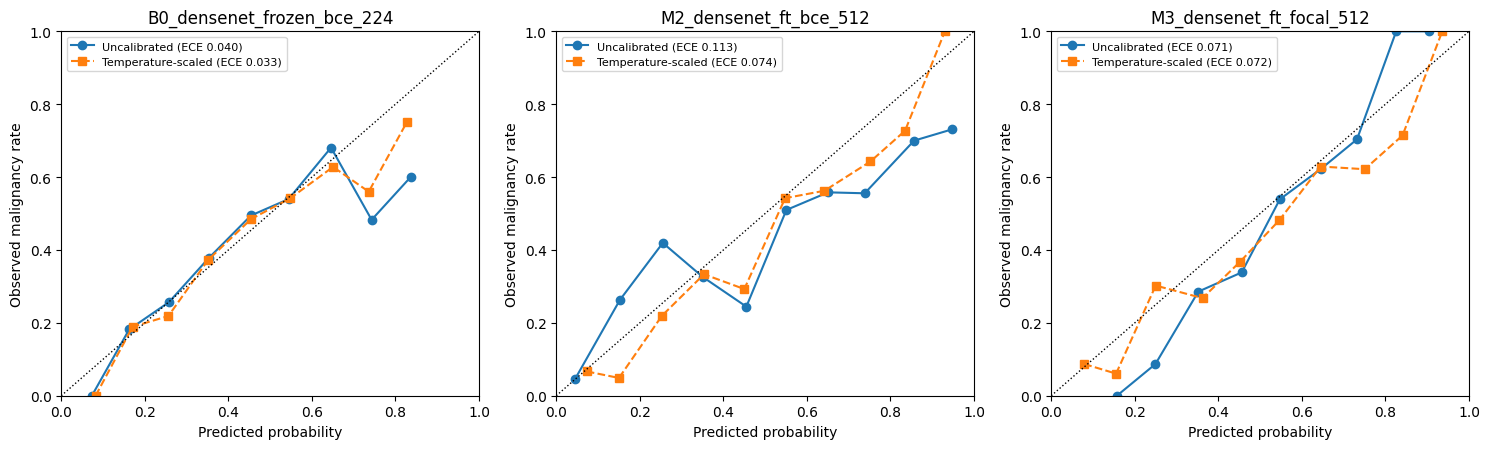

In [26]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def to_logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def nll(y, p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


def fit_temperature(y, p):
    z = to_logit(p)
    return float(minimize_scalar(lambda T: nll(y, sigmoid(z / T)), bounds=(0.05, 20), method="bounded").x)


def ece(y, p, bins=10):
    idx = np.clip((p * bins).astype(int), 0, bins - 1)
    return float(sum(abs(y[idx == b].mean() - p[idx == b].mean()) * (idx == b).mean()
                     for b in range(bins) if (idx == b).any()))


def reliability(y, p, bins=10):
    idx = np.clip((p * bins).astype(int), 0, bins - 1)
    keep = [b for b in range(bins) if (idx == b).any()]
    return (np.array([p[idx == b].mean() for b in keep]), np.array([y[idx == b].mean() for b in keep]),
            np.array([(idx == b).sum() for b in keep]))


CALIB, cal_rows = {}, []
for name in available:
    pv, pt = split_probs(name, "val"), split_probs(name, "test")
    T = fit_temperature(y_val, pv)
    pt_cal = sigmoid(to_logit(pt) / T)
    CALIB[name] = {"temperature": T}
    cal_rows.append({"Model": name, "Temperature": round(T, 3),
                     "ECE before": round(ece(y_test, pt), 3), "ECE after": round(ece(y_test, pt_cal), 3),
                     "Brier before": round(float(np.mean((pt - y_test) ** 2)), 3),
                     "Brier after": round(float(np.mean((pt_cal - y_test) ** 2)), 3),
                     "NLL before": round(nll(y_test, pt), 3), "NLL after": round(nll(y_test, pt_cal), 3)})
calibration = pd.DataFrame(cal_rows)
calibration.to_csv(TABLES / "calibration.csv", index=False)
display(calibration)

show = [n for n in ["B0_densenet_frozen_bce_224", "M2_densenet_ft_bce_512", PROPOSED] if n in available]
fig, axes = plt.subplots(1, len(show), figsize=(5 * len(show), 4.6), squeeze=False)
for ax, name in zip(axes[0], show):
    pt = split_probs(name, "test")
    for probs, label, style in [(pt, "Uncalibrated", "o-"),
                                (sigmoid(to_logit(pt) / CALIB[name]["temperature"]), "Temperature-scaled", "s--")]:
        conf, acc, n = reliability(y_test, probs)
        ax.plot(conf, acc, style, label=f"{label} (ECE {ece(y_test, probs):.3f})")
    ax.plot([0, 1], [0, 1], "k:", lw=1)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Predicted probability", ylabel="Observed malignancy rate", title=name)
    ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
savefig(fig, "fig_calibration")
plt.show()

### 7.2 Comparing with the radiologists (BI-RADS)

CBIS-DDSM only has mammograms where a lesion was biopsied, there are no normal screening cases. So the task here is diagnosis (is a suspicious finding benign or malignant) and not screening. Because of this it wouldn't be fair to compare with screening sensitivity numbers like 86.9% (Lehman et al., 2017).

A better comparison is already in the dataset. Every lesion has the BI-RADS score (1 to 5) that the original radiologists gave it. Using BI-RADS as a score gives a ROC curve for the radiologists on the same test images, and BI-RADS ≥ 4 (where a biopsy is recommended) gives their clinical threshold. BI-RADS 0 is left out because it means the assessment was incomplete.

Images with BI-RADS 1-5: 425 / 458
ΔAUC (model − BI-RADS): -0.061 (95% CI -0.130 to +0.008, p=0.079)
Model sensitivity at the radiologists' BI-RADS≥4 specificity (read off the ROC curve): 86.3%


,Reader,AUC (95% CI),Operating point,Sensitivity %,Specificity %
0,"Radiologists (BI-RADS, ordinal)",0.790 (0.738–0.837),BI-RADS ≥ 4,90.1 (84.2–95.5),42.8 (33.9–51.2)
1,M3_densenet_ft_focal_512,0.729 (0.668–0.784),Youden (validation),66.5 (57.9–74.4),68.7 (62.1–75.5)


col_0,Benign,Malignant
birads,,
2,45,1
3,59,17
4,137,87
5,2,77


saved /content/drive/MyDrive/CM3070_project/figures/fig_roc_vs_birads.png


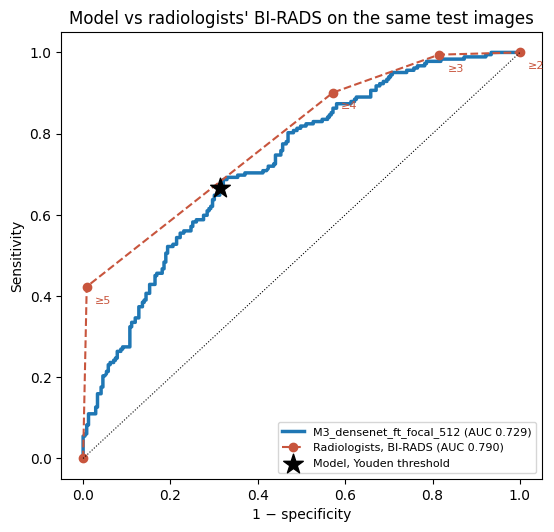

In [27]:
has_birads = test_info.birads.between(1, 5).values
yb = y_test[has_birads]
rb = test_info.birads.values[has_birads].astype(float)
pb = p_prop_test[has_birads]
boot_b = PatientBootstrap(test_info.patient_id.values[has_birads], CONFIG["n_bootstrap"])

auc_rad = boot_b.ci(roc_auc_score, yb, rb)
auc_mod = boot_b.ci(roc_auc_score, yb, pb)
d_auc = paired_auc_diff(boot_b, yb, pb, rb)
_, rad_op = ci_metrics(boot_b, yb, rb, 4)
_, mod_op = ci_metrics(boot_b, yb, pb, THRESHOLDS[PROPOSED]["youden"])
fpr_m, tpr_m, _ = roc_curve(yb, pb)
sens_at_rad_spec = float(np.interp(1 - rad_op["specificity"][0], fpr_m, tpr_m))

birads_table = pd.DataFrame([
    {"Reader": "Radiologists (BI-RADS, ordinal)", "AUC (95% CI)": fmt(auc_rad),
     "Operating point": "BI-RADS ≥ 4", "Sensitivity %": fmt(rad_op["sensitivity"], True),
     "Specificity %": fmt(rad_op["specificity"], True)},
    {"Reader": f"{PROPOSED}", "AUC (95% CI)": fmt(auc_mod),
     "Operating point": "Youden (validation)", "Sensitivity %": fmt(mod_op["sensitivity"], True),
     "Specificity %": fmt(mod_op["specificity"], True)},
])
print(f"Images with BI-RADS 1-5: {has_birads.sum()} / {len(has_birads)}")
print(f"ΔAUC (model − BI-RADS): {d_auc[0]:+.3f} (95% CI {d_auc[1]:+.3f} to {d_auc[2]:+.3f}, p={d_auc[3]:.3f})")
print(f"Model sensitivity at the radiologists' BI-RADS≥4 specificity (read off the ROC curve): {100 * sens_at_rad_spec:.1f}%")
display(birads_table)
display(pd.crosstab(test_info.birads[has_birads].astype(int), np.where(yb == 1, "Malignant", "Benign")))
birads_table.to_csv(TABLES / "birads_reference.csv", index=False)

fig, ax = plt.subplots(figsize=(6.2, 5.8))
ax.plot(fpr_m, tpr_m, lw=2.5, label=f"{PROPOSED} (AUC {auc_mod[0]:.3f})")
fpr_r, tpr_r, thr_r = roc_curve(yb, rb)
ax.plot(fpr_r, tpr_r, "o--", color="#C8553D", label=f"Radiologists, BI-RADS (AUC {auc_rad[0]:.3f})")
for f, t, th in zip(fpr_r, tpr_r, thr_r):
    if 1 <= th <= 5:
        ax.annotate(f"≥{int(th)}", (f, t), textcoords="offset points", xytext=(6, -12), fontsize=8, color="#C8553D")
ax.scatter([1 - mod_op["specificity"][0]], [mod_op["sensitivity"][0]], marker="*", s=220, color="black", zorder=5,
           label="Model, Youden threshold")
ax.plot([0, 1], [0, 1], "k:", lw=0.8)
ax.set(xlabel="1 − specificity", ylabel="Sensitivity", title="Model vs radiologists' BI-RADS on the same test images")
ax.legend(fontsize=8, loc="lower right")
savefig(fig, "fig_roc_vs_birads")
plt.show()

### 7.3 Subgroup analysis (bias and hidden stratification)

One overall AUC can hide groups where the model does badly (Oakden-Rayner et al., 2020). So the results of the proposed model are split by breast density (lesions are harder to see in dense tissue), lesion type, view and the subtlety rating from the radiologists. CBIS-DDSM doesn't have age or ethnicity, so demographic fairness couldn't be checked, and this is mentioned as a limitation in the report.

,Group,Subgroup,Images,Malignant,AUC (95% CI),Sensitivity %,Specificity %
0,Breast density,Density 1,54,17,0.800 (0.603–0.949),76.5 (50.0–100.0),75.7 (58.5–91.4)
1,Breast density,Density 2,197,98,0.720 (0.632–0.812),73.5 (62.4–84.6),58.6 (47.5–68.8)
2,Breast density,Density 3,138,56,0.738 (0.623–0.839),60.7 (42.9–77.8),72.0 (59.5–83.3)
3,Breast density,Density 4,69,22,0.632 (0.482–0.773),59.1 (33.3–82.6),70.2 (56.9–83.0)
4,Lesion type,Calcification,217,91,0.748 (0.665–0.822),71.4 (59.8–81.9),68.3 (58.1–77.4)
5,Lesion type,Mass,241,102,0.712 (0.635–0.789),65.7 (54.2–76.6),66.2 (58.0–74.8)
6,View,CC,204,89,0.720 (0.647–0.789),68.5 (58.5–77.6),65.2 (56.2–74.4)
7,View,MLO,254,104,0.738 (0.670–0.797),68.3 (58.1–75.8),68.7 (61.0–75.6)
8,Subtlety,1–2 (subtle),86,42,0.623 (0.470–0.763),64.3 (45.0–81.6),50.0 (32.5–66.7)
9,Subtlety,3,138,52,0.761 (0.647–0.853),69.2 (54.3–82.0),74.4 (64.8–83.5)


saved /content/drive/MyDrive/CM3070_project/figures/fig_subgroups.png


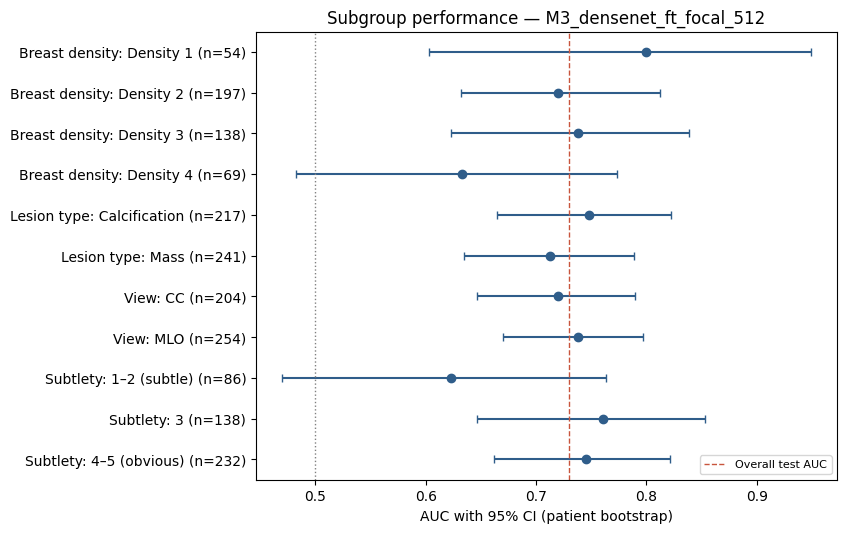

In [28]:
t_prop = THRESHOLDS[PROPOSED]["youden"]
subgroups = {
    "Breast density": test_info.breast_density.map(lambda d: f"Density {int(d)}" if pd.notna(d) else np.nan),
    "Lesion type": test_info.lesion_type,
    "View": test_info.view,
    "Subtlety": pd.cut(test_info.subtlety, [0, 2, 3, 5], labels=["1–2 (subtle)", "3", "4–5 (obvious)"]).astype(object),
}
n_sub = max(200, CONFIG["n_bootstrap"] // 2)
sub_rows = []
for group, labels in subgroups.items():
    for level in sorted(labels.dropna().unique()):
        m = (labels == level).values
        yy, pp = y_test[m], p_prop_test[m]
        b = PatientBootstrap(test_info.patient_id.values[m], n_sub)
        auc = b.ci(roc_auc_score, yy, pp) if len(np.unique(yy)) == 2 else (np.nan, np.nan, np.nan)
        _, cis = ci_metrics(b, yy, pp, t_prop)
        sub_rows.append({"Group": group, "Subgroup": level, "Images": int(m.sum()), "Malignant": int(yy.sum()),
                         "AUC": auc[0], "AUC lo": auc[1], "AUC hi": auc[2],
                         "AUC (95% CI)": fmt(auc), "Sensitivity %": fmt(cis["sensitivity"], True),
                         "Specificity %": fmt(cis["specificity"], True)})
subgroup_table = pd.DataFrame(sub_rows)
subgroup_table.to_csv(TABLES / "subgroups.csv", index=False)
display(subgroup_table.drop(columns=["AUC", "AUC lo", "AUC hi"]))

plot_df = subgroup_table.dropna(subset=["AUC"]).iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(plot_df) + 1.2))
ax.errorbar(plot_df["AUC"], range(len(plot_df)),
            xerr=[plot_df["AUC"] - plot_df["AUC lo"], plot_df["AUC hi"] - plot_df["AUC"]],
            fmt="o", color="#2F5D8A", capsize=3)
ax.axvline(AUC_CI[PROPOSED][0], color="#C8553D", ls="--", lw=1, label="Overall test AUC")
ax.axvline(0.5, color="grey", ls=":", lw=1)
ax.set_yticks(range(len(plot_df)), [f"{g}: {s} (n={n})" for g, s, n in zip(plot_df.Group, plot_df.Subgroup, plot_df.Images)])
ax.set_xlabel("AUC with 95% CI (patient bootstrap)")
ax.set_title(f"Subgroup performance — {PROPOSED}")
ax.legend(fontsize=8)
savefig(fig, "fig_subgroups")
plt.show()

### 7.4 Multi-view fusion (per breast)

Radiologists look at the CC and MLO views of a breast together. To do something similar, the model's predictions are averaged over all the images of the same breast. This doesn't need any retraining.

In [29]:
mv_rows = []
for name in available:
    df = test_info[["breast_id", "patient_id", "label"]].assign(prob=split_probs(name, "test"))
    br = df.groupby("breast_id").agg(patient_id=("patient_id", "first"), label=("label", "max"),
                                     prob=("prob", "mean"), n_images=("prob", "size"))
    b = PatientBootstrap(br.patient_id.values, CONFIG["n_bootstrap"])
    auc_b = b.ci(roc_auc_score, br.label.values, br.prob.values)
    mv_rows.append({"Model": name, "Image-level AUC": fmt(AUC_CI[name]), "Breast-level AUC": fmt(auc_b),
                    "Change": f"{auc_b[0] - AUC_CI[name][0]:+.3f}", "Breasts": len(br),
                    "Breasts with ≥2 images": int((br.n_images > 1).sum())})
multiview = pd.DataFrame(mv_rows)
multiview.to_csv(TABLES / "multiview.csv", index=False)
display(multiview)

,Model,Image-level AUC,Breast-level AUC,Change,Breasts,Breasts with ≥2 images
0,B0_densenet_frozen_bce_224,0.679 (0.620–0.733),0.696 (0.634–0.757),+0.017,257,189
1,M1_custom_cnn_focal_512,0.653 (0.590–0.711),0.647 (0.578–0.709),-0.006,257,189
2,M2_densenet_ft_bce_512,0.748 (0.690–0.805),0.748 (0.688–0.805),+0.000,257,189
3,M3_densenet_ft_focal_512,0.730 (0.670–0.789),0.731 (0.670–0.791),+0.001,257,189
4,A1_densenet_ft_focal_noaug_512,0.769 (0.714–0.821),0.764 (0.705–0.818),-0.005,257,189
5,A2_densenet_ft_focal_224,0.640 (0.582–0.699),0.645 (0.577–0.710),+0.004,257,189
6,A3_efficientnetb0_ft_focal_512,0.711 (0.654–0.768),0.728 (0.667–0.786),+0.017,257,189
7,A4_resnet50v2_ft_focal_512,0.751 (0.694–0.806),0.764 (0.703–0.821),+0.013,257,189


## 8. Grad-CAM and checking the heatmaps

Grad-CAM (Selvaraju et al., 2017) weights the last convolutional feature maps by the gradient of the malignancy logit, which shows the areas that pushed the prediction up. It is easy to read too much into heatmaps (Adebayo et al., 2018; Saporta et al., 2022), so they are also measured against the ROI masks drawn by the radiologists:

- Pointing game (Zhang et al., 2018): is the highest point of the heatmap within 15 px (at 512 px) of a marked lesion? This is compared with how often a random point would hit, both over the whole image and only inside the breast.
- Concentration: how much of the heatmap falls inside the lesion, divided by how much of the image the lesion covers (1 means no better than spreading it evenly).
- Shortcut check: how much of the heatmap is outside the breast, where things like film labels and scanner marks are.
- Sanity check: the same model but with random weights. If this scored just as well, it would mean Grad-CAM is only showing the structure of the image and not what the model actually learned.

In [30]:
def load_trained_model(name):
    keras.backend.clear_session()
    model = build_model(EXPERIMENTS[name], name)
    model.load_weights(MODELS / f"{name}.weights.h5")
    return model


def make_cam_fn(model):
    prep, backbone, head = (model.get_layer(n) for n in ("prep", "backbone", "head"))
    head_logit = keras.Model(head.inputs, head.get_layer("logit").output)

    def cam_fn(X):
        x = tf.convert_to_tensor(X[..., None], tf.float32)
        with tf.GradientTape() as tape:
            feats = backbone(prep(x, training=False), training=False)
            tape.watch(feats)
            logits = head_logit(feats, training=False)
        grads = tf.cast(tape.gradient(logits, feats), tf.float32)
        feats = tf.cast(feats, tf.float32)
        weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
        return tf.nn.relu(tf.reduce_sum(weights * feats, axis=-1)).numpy()
    return cam_fn


def compute_cams(model, X, batch=16):
    fn = make_cam_fn(model)
    return np.concatenate([fn(X[i:i + batch]) for i in range(0, len(X), batch)])


def upsample_cam(cam, size):
    up = np.maximum(cv2.resize(cam.astype(np.float32), (size, size), interpolation=cv2.INTER_LINEAR), 0)
    return up / up.max() if up.max() > 0 else up


def breast_mask(img):
    _, b = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(b.astype(np.uint8))
    if n <= 1:
        return b.astype(bool)
    return lab == 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))


TOL = max(1, round(15 * S / 512))
KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * TOL + 1, 2 * TOL + 1))


def localisation_metrics(cam, lesion, breast):
    lesion_tol = cv2.dilate(lesion.astype(np.uint8), KERNEL).astype(bool)
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    total = cam.sum() + 1e-8
    return {"hit": float(lesion_tol[peak]), "chance_image": lesion_tol.mean(),
            "chance_breast": (lesion_tol & breast).sum() / max(breast.sum(), 1),
            "energy_in_lesion": (cam * lesion).sum() / total, "lesion_area": lesion.mean(),
            "energy_outside_breast": (cam * ~breast).sum() / total}


BREAST = np.stack([breast_mask(x) for x in X_full[IDX["test"]]])
HAS_MASK = M_test.reshape(len(M_test), -1).any(1)


def localisation_frame(cams):
    return pd.DataFrame([{"k": k, **localisation_metrics(upsample_cam(cams[k], S), M_test[k], BREAST[k])}
                         for k in np.flatnonzero(HAS_MASK)])

In [31]:
# Save each model's heatmaps to Drive straight away so a crash can carry on from where it stopped
CAM_DIR = LOGS / "gradcam"
CAM_DIR.mkdir(exist_ok=True)
RANDOM_NAME = f"{PROPOSED} (random weights)"
CAMS, LOC = {}, {}
for name in available + [RANDOM_NAME]:
    path = CAM_DIR / f"{name.replace(' ', '_').replace('(', '').replace(')', '')}.npy"
    if not path.exists():
        print("Grad-CAM:", name)
        keras.backend.clear_session()
        if name == RANDOM_NAME:
            keras.utils.set_random_seed(SEED)
            model = build_model(EXPERIMENTS[PROPOSED], "random_weights", pretrained=False)
            size = EXPERIMENTS[PROPOSED]["size"]
        else:
            model = load_trained_model(name)
            size = EXPERIMENTS[name]["size"]
        np.save(path, compute_cams(model, get_split(size, "test")[0], batch=8))
        del model
        keras.backend.clear_session()
        gc.collect()
    CAMS[name] = np.load(path)
    LOC[name] = localisation_frame(CAMS[name])

loc_rows = []
for name, df in LOC.items():
    b = PatientBootstrap(test_info.patient_id.values[df.k.values], CONFIG["n_bootstrap"])
    hit = b.ci(np.mean, df.hit.values)
    malignant = y_test[df.k.values] == 1
    loc_rows.append({"Model": name, "Pointing-game hit % (95% CI)": fmt(hit, True),
                     "Hit % (malignant only)": round(100 * df.hit[malignant].mean(), 1),
                     "Chance % (whole image)": round(100 * df.chance_image.mean(), 1),
                     "Chance % (within breast)": round(100 * df.chance_breast.mean(), 1),
                     "Concentration (median)": round(float((df.energy_in_lesion / df.lesion_area).median()), 2),
                     "Energy outside breast %": round(100 * df.energy_outside_breast.mean(), 1),
                     "hit_rate": hit[0]})
localisation = pd.DataFrame(loc_rows)
localisation.drop(columns=["hit_rate"]).to_csv(TABLES / "gradcam_localisation.csv", index=False)
display(localisation.drop(columns=["hit_rate"]))

,Model,Pointing-game hit % (95% CI),Hit % (malignant only),Chance % (whole image),Chance % (within breast),Concentration (median),Energy outside breast %
0,B0_densenet_frozen_bce_224,2.8 (1.5–4.5),4.7,2.4,6.4,0.83,63.700001
1,M1_custom_cnn_focal_512,5.7 (3.3–8.1),8.8,2.4,6.4,1.53,39.799999
2,M2_densenet_ft_bce_512,10.5 (7.2–14.0),19.7,2.4,6.4,0.80,62.500000
3,M3_densenet_ft_focal_512,11.4 (8.0–14.9),20.7,2.4,6.4,0.60,59.700001
4,A1_densenet_ft_focal_noaug_512,5.2 (2.7–7.9),8.8,2.4,6.4,0.61,59.900002
5,A2_densenet_ft_focal_224,2.6 (1.1–4.3),5.2,2.4,6.4,0.04,63.599998
6,A3_efficientnetb0_ft_focal_512,16.2 (12.5–20.1),25.4,2.4,6.4,1.59,48.900002
7,A4_resnet50v2_ft_focal_512,15.7 (12.2–19.2),26.4,2.4,6.4,1.06,57.900002
8,M3_densenet_ft_focal_512 (random weights),4.8 (2.9–6.9),7.3,2.4,6.4,0.00,29.900000


saved /content/drive/MyDrive/CM3070_project/figures/fig_gradcam_examples.png


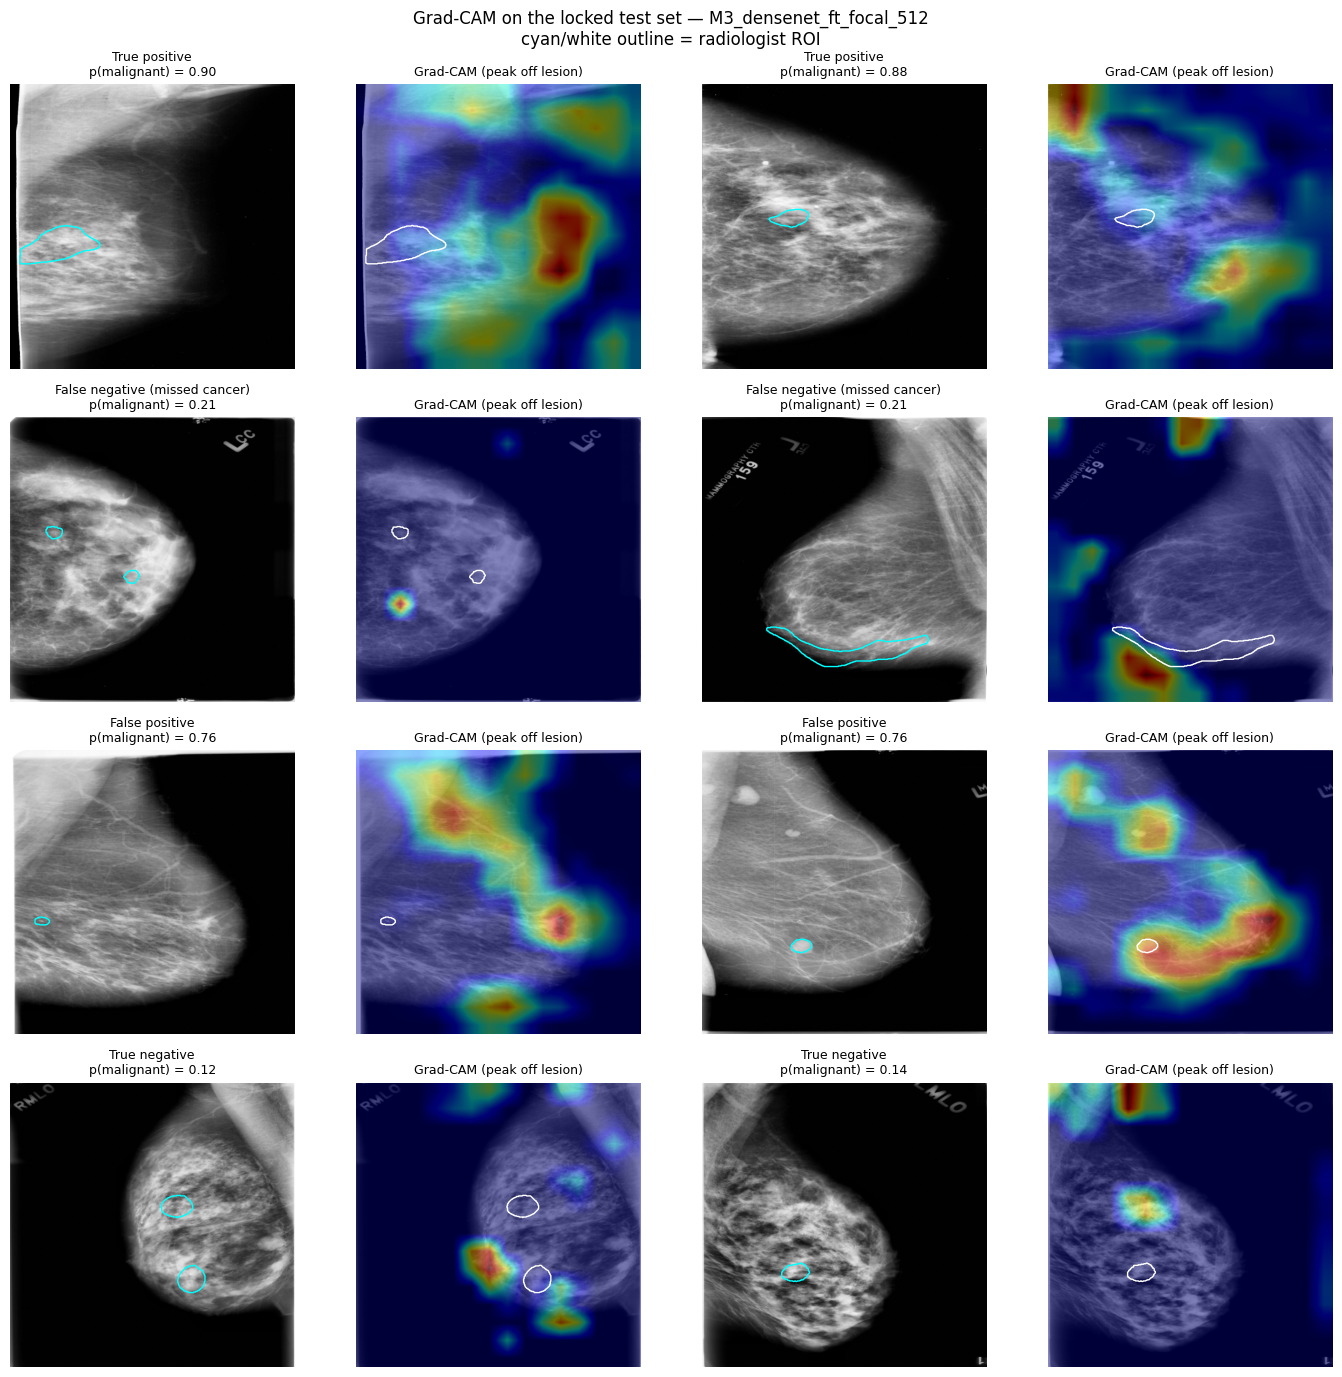

saved /content/drive/MyDrive/CM3070_project/figures/fig_gradcam_localisation.png


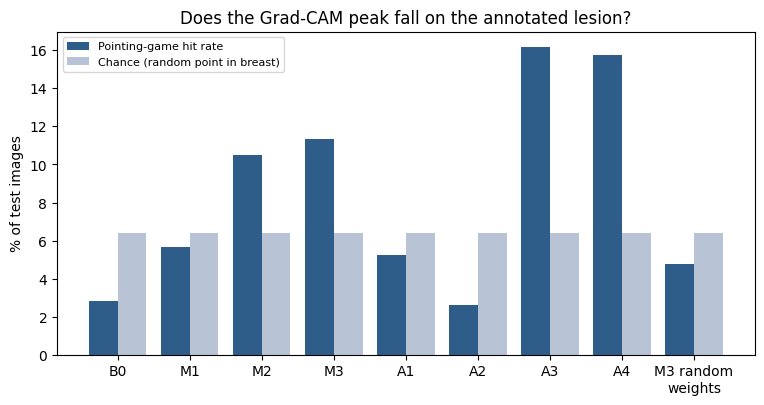

In [32]:
t = THRESHOLDS[PROPOSED]["youden"]
outcome = np.where(y_test == 1, np.where(p_prop_test >= t, "TP", "FN"), np.where(p_prop_test >= t, "FP", "TN"))
picks = []
for o in ["TP", "FN", "FP", "TN"]:
    ks = np.flatnonzero((outcome == o) & HAS_MASK)
    order = np.argsort(p_prop_test[ks])
    ks = ks[order[::-1]] if o in ("TP", "FP") else ks[order]
    # Two different patients per row so the duplicate CBIS-DDSM files don't show up twice
    chosen, seen = [], set()
    for kk in ks:
        if test_info.patient_id[kk] not in seen:
            chosen.append(kk)
            seen.add(test_info.patient_id[kk])
        if len(chosen) == 2:
            break
    picks.append((o, chosen))

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
titles = {"TP": "True positive", "FN": "False negative (missed cancer)", "FP": "False positive", "TN": "True negative"}
for r, (o, ks) in enumerate(picks):
    for c in range(2):
        ax_img, ax_cam = axes[r, 2 * c], axes[r, 2 * c + 1]
        ax_img.axis("off")
        ax_cam.axis("off")
        if c >= len(ks):
            continue
        k = ks[c]
        img = X_full[IDX["test"][k]]
        cam = upsample_cam(CAMS[PROPOSED][k], S)
        ax_img.imshow(img, cmap="gray")
        ax_img.contour(M_test[k], levels=[0.5], colors="cyan", linewidths=1)
        ax_img.set_title(f"{titles[o]}\np(malignant) = {p_prop_test[k]:.2f}", fontsize=9)
        ax_cam.imshow(img, cmap="gray")
        ax_cam.imshow(cam, cmap="jet", alpha=0.45)
        ax_cam.contour(M_test[k], levels=[0.5], colors="white", linewidths=1)
        hit = LOC[PROPOSED].set_index("k").hit.get(k, np.nan)
        ax_cam.set_title(f"Grad-CAM ({'peak on lesion' if hit == 1 else 'peak off lesion'})", fontsize=9)
fig.suptitle(f"Grad-CAM on the locked test set — {PROPOSED}\ncyan/white outline = radiologist ROI", fontsize=12)
fig.tight_layout()
savefig(fig, "fig_gradcam_examples")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.2))
xs = np.arange(len(localisation))
ax.bar(xs - 0.2, 100 * localisation.hit_rate, width=0.4, label="Pointing-game hit rate", color="#2F5D8A")
ax.bar(xs + 0.2, localisation["Chance % (within breast)"], width=0.4, label="Chance (random point in breast)", color="#B8C4D6")
ax.set_xticks(xs, [n.split("_")[0] if "random" not in n else "M3 random\nweights" for n in localisation.Model])
ax.set_ylabel("% of test images")
ax.set_title("Does the Grad-CAM peak fall on the annotated lesion?")
ax.legend(fontsize=8)
savefig(fig, "fig_gradcam_localisation")
plt.show()

## 9. Export

This saves `results_summary.md`, which has all the tables from the report, and `results_bundle.zip` with the figures, tables, logs, predictions, demo examples and the weights of the proposed model.

In [33]:
(MODELS / "deploy_config.json").write_text(json.dumps({
    "model": PROPOSED, "input_size": EXPERIMENTS[PROPOSED]["size"],
    "temperature": CALIB[PROPOSED]["temperature"], "thresholds": THRESHOLDS[PROPOSED]}, indent=2))


def to_md(df):
    try:
        return df.to_markdown(index=False)
    except ImportError:
        return "```\n" + df.to_string(index=False) + "\n```"


sections = [
    ("Split summary", split_summary.reset_index()),
    ("Leakage audit", leakage_audit),
    ("Model sizes", model_sizes),
    ("Experiments", exp_table),
    ("Training efficiency", efficiency),
    ("Test metrics (locked test set)", results_table),
    ("Paired AUC comparison vs proposed", auc_comparison),
    ("Calibration", calibration),
    ("BI-RADS radiologist reference", birads_table),
    ("Subgroups (proposed model)", subgroup_table.drop(columns=["AUC", "AUC lo", "AUC hi"])),
    ("Multi-view fusion", multiview),
    ("Grad-CAM localisation", localisation.drop(columns=["hit_rate"])),
]
summary_md = [f"# Results summary\n\nProposed model: `{PROPOSED}`\n",
              f"Thresholds (validation): `{json.dumps(THRESHOLDS[PROPOSED])}`\n",
              f"Preprocessing build times (s): `{json.dumps({k: round(v) for k, v in BUILD_TIMES.items()})}`\n",
              f"BI-RADS: ΔAUC model − radiologists = {d_auc[0]:+.3f} (95% CI {d_auc[1]:+.3f} to {d_auc[2]:+.3f}, "
              f"p = {d_auc[3]:.3f}); model sensitivity at BI-RADS≥4 specificity = {100 * sens_at_rad_spec:.1f}%\n"]
summary_md += [f"## {title}\n\n{to_md(df)}\n" for title, df in sections]
(WORK / "results_summary.md").write_text("\n".join(summary_md))
print("\n".join(summary_md)[:3000])

# Results summary

Proposed model: `M3_densenet_ft_focal_512`

Thresholds (validation): `{"0.50": 0.5, "youden": 0.4982281625270843, "sens90": 0.4061805009841919}`

Preprocessing build times (s): `{"images_512": 574, "images_224": 4, "masks_test_512": 1, "masks_test_512_v2": 41}`

BI-RADS: ΔAUC model − radiologists = -0.061 (95% CI -0.130 to +0.008, p = 0.079); model sensitivity at BI-RADS≥4 specificity = 86.3%

## Split summary

| split   |   images |   patients |   malignant |   malignant_% |
|:--------|---------:|-----------:|------------:|--------------:|
| train   |     2190 |       1096 |         977 |          44.6 |
| val     |      455 |        235 |         205 |          45.1 |
| test    |      458 |        235 |         193 |          42.1 |

## Leakage audit

| Split strategy                     | Test images sharing a patient with training   |   Near-duplicate pairs crossing partitions |
|:-----------------------------------|:----------------------------------------------

## 10. Demo

A mammogram (JPEG or PNG) can be uploaded here. The app does the same CLAHE preprocessing, gives the calibrated probability of malignancy, shows the decision at the high-sensitivity and the balanced thresholds (both picked on validation), and draws the Grad-CAM heatmap on top of the image. The example images are from the test set. This is only a research prototype and not a medical device.

saved /content/drive/MyDrive/CM3070_project/figures/fig_demo_examples.png


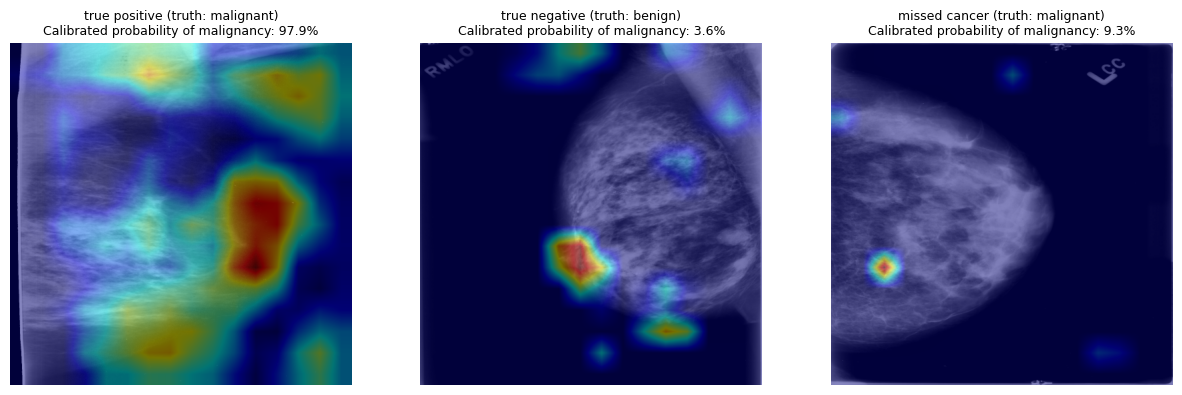

In [34]:
SP = EXPERIMENTS[PROPOSED]["size"]
demo_model = load_trained_model(PROPOSED)
demo_cam = make_cam_fn(demo_model)
T_PROP, TH = CALIB[PROPOSED]["temperature"], THRESHOLDS[PROPOSED]


def analyse(image):
    image = np.asarray(image)
    gray = image if image.ndim == 2 else cv2.cvtColor(image[..., :3].astype(np.uint8), cv2.COLOR_RGB2GRAY)
    x = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray.astype(np.uint8))
    x = cv2.resize(x, (SP, SP), interpolation=cv2.INTER_AREA)
    p_raw = float(predict_probs(demo_model, x[None], 1)[0])
    p_cal = float(sigmoid(to_logit(np.array([p_raw]))[0] / T_PROP))
    cam = upsample_cam(demo_cam(x[None])[0], SP)
    heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)[..., ::-1]
    overlay = (0.55 * np.repeat(x[..., None], 3, -1) + 0.45 * heat).astype(np.uint8)
    screening = "FLAG for radiologist review" if p_raw >= TH["sens90"] else "not flagged"
    balanced = "suspicious" if p_raw >= TH["youden"] else "not suspicious"
    text = (f"**Calibrated probability of malignancy:** {p_cal:.1%}\n\n"
            f"**High-sensitivity operating point** (threshold {TH['sens90']:.2f}): {screening}\n\n"
            f"**Balanced operating point** (threshold {TH['youden']:.2f}): {balanced}\n\n"
            "_Research prototype trained on CBIS-DDSM (digitised film, lesion-containing images only). "
            "Not a medical device._")
    return overlay, text


example_rows = []
for o, pick in [("true_positive", np.argmax(np.where(y_test == 1, p_prop_test, -1))),
                ("true_negative", np.argmin(np.where(y_test == 0, p_prop_test, 2))),
                ("missed_cancer", np.argmin(np.where(y_test == 1, p_prop_test, 2)))]:
    src = Path(test_info.full_path[pick])
    dst = DEMO / f"example_{o}.jpg"
    if not dst.exists():
        cv2.imwrite(str(dst), cv2.imread(str(src), cv2.IMREAD_GRAYSCALE))
    example_rows.append((o, dst, int(y_test[pick])))

fig, axes = plt.subplots(1, len(example_rows), figsize=(5 * len(example_rows), 5.6))
for ax, (o, path, label) in zip(np.atleast_1d(axes), example_rows):
    overlay, text = analyse(cv2.imread(str(path), cv2.IMREAD_GRAYSCALE))
    ax.imshow(overlay)
    ax.axis("off")
    prob_line = text.split("\n")[0].replace("**", "")
    ax.set_title(f"{o.replace('_', ' ')} (truth: {'malignant' if label else 'benign'})\n{prob_line}", fontsize=9)
savefig(fig, "fig_demo_examples")
plt.show()

In [35]:
bundle = WORK / "results_bundle.zip"
with zipfile.ZipFile(bundle, "w", zipfile.ZIP_DEFLATED) as z:
    for folder in [FIGS, TABLES, LOGS, PREDS, DEMO]:
        for f in folder.rglob("*"):
            if f.is_file():
                z.write(f, f.relative_to(WORK))
    z.write(WORK / "results_summary.md", "results_summary.md")
    for f in [MODELS / f"{PROPOSED}.weights.h5", MODELS / "deploy_config.json"]:
        z.write(f, f.relative_to(WORK))
print(f"{bundle} ({bundle.stat().st_size / 1e6:.1f} MB)")
if IN_COLAB:
    from google.colab import files
    files.download(str(bundle))

/content/drive/MyDrive/CM3070_project/results_bundle.zip (53.9 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
if CONFIG["run_demo"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gradio"], check=True)
    import gradio as gr
    demo = gr.Interface(
        fn=analyse,
        inputs=gr.Image(type="numpy", label="Mammogram"),
        outputs=[gr.Image(label="Grad-CAM overlay"), gr.Markdown()],
        examples=[[str(path)] for _, path, _ in example_rows],
        title="CBIS-DDSM second-reader prototype",
        description="Fine-tuned DenseNet121 with focal loss. Calibrated malignancy probability, "
                    "validation-chosen operating points and a Grad-CAM explanation.",
    )
    demo.launch(share=True)